   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 9.2 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 12.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 12.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 12.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
Verfügbare Variablen in der Datei:
M: (200000, 53)
t: (200000, 1)
x: (1, 1)
y: (53, 1)
Suche nach alternativen Variablennamen...
M: Shape (200000, 53)
t: Shape (200000, 1)
x: Shape (1, 1)
y: Shape (53, 1)


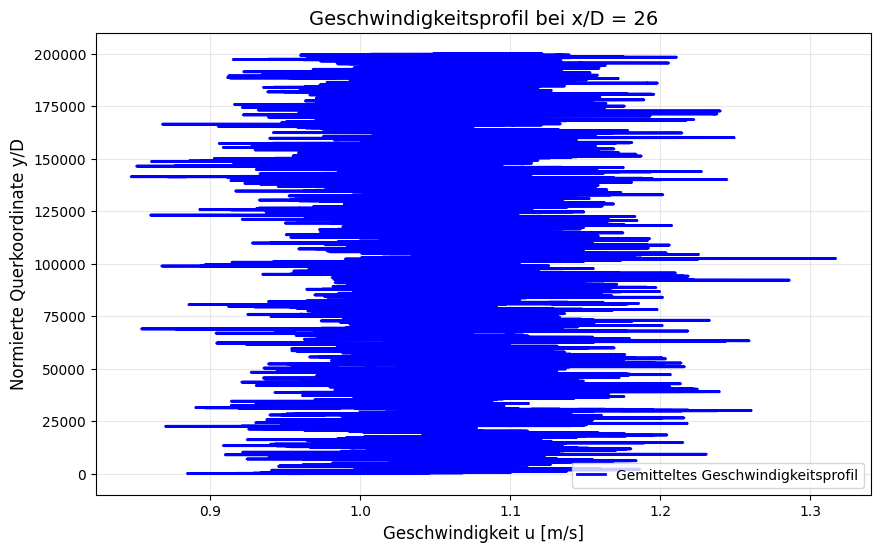

In [5]:
!pip install scipy numpy matplotlib
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# MAT-Datei laden
data = scipy.io.loadmat('STD_u10_xd26.mat')

# Überprüfen der verfügbaren Variablen
print("Verfügbare Variablen in der Datei:")
for key in data.keys():
    if not key.startswith('__'):
        print(f"{key}: {data[key].shape}")

# Annahme: Die Datenstruktur enthält Geschwindigkeitsmessungen
# Typische Variablennamen könnten sein:
# - 'u' oder 'velocity' für Geschwindigkeitsdaten
# - 'y' oder 'y_position' für Querkoordinaten
# - 't' oder 'time' für Zeit

# Daten extrahieren (Variablennamen anpassen basierend auf der Ausgabe oben)
try:
    # Fall 1: Wenn Geschwindigkeitsdaten als 2D-Array (y-Position × Zeit)
    u_data = data['u']  # oder den tatsächlichen Variablennamen verwenden
    
    # Querkoordinaten (falls vorhanden)
    if 'y' in data:
        y_coords = data['y'].flatten()
    else:
        # Falls y-Koordinaten nicht explizit vorhanden, aus der Datenstruktur ableiten
        y_coords = np.arange(u_data.shape[0])
    
except KeyError:
    # Fall 2: Andere mögliche Variablennamen
    print("Suche nach alternativen Variablennamen...")
    for key in data.keys():
        if not key.startswith('__') and hasattr(data[key], 'shape'):
            print(f"{key}: Shape {data[key].shape}")
    
    # Hier müssten Sie den tatsächlichen Variablennamen anpassen
    u_data = data[list(data.keys())[3]]  # Erste nicht-system Variable
    y_coords = np.arange(u_data.shape[0])

# Geschwindigkeit über die Zeit mitteln (zeitliche Mittelung)
u_mean = np.mean(u_data, axis=1)  # Mittelung über die Zeitachse

# Querkoordinate normieren (angenommen D = 1 oder entsprechend anpassen)
D = 1.0  # Charakteristische Länge - ggf. anpassen
y_norm = y_coords / D

# Diagramm erstellen
plt.figure(figsize=(10, 6))
plt.plot(u_mean, y_norm, 'b-', linewidth=2, label='Gemitteltes Geschwindigkeitsprofil')
plt.xlabel('Geschwindigkeit u [m/s]', fontsize=12)
plt.ylabel('Normierte Querkoordinate y/D', fontsize=12)
plt.title('Geschwindigkeitsprofil bei x/D = 26', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

Datenstruktur:
M (Geschwindigkeit): (200000, 53)
t (Zeit): (200000,), Bereich: 0.000 bis 10.000 s
x (Streamwise): (1,), Werte: [260]
y (Querkoordinate): (53,), Bereich: -77.002 bis 78.998 m

Berechnete charakteristische Länge D: 10.0000 m
Normierte Querkoordinate: -7.700 bis 7.900 y/D


ValueError: x and y must have same first dimension, but have shapes (53,) and (200000,)

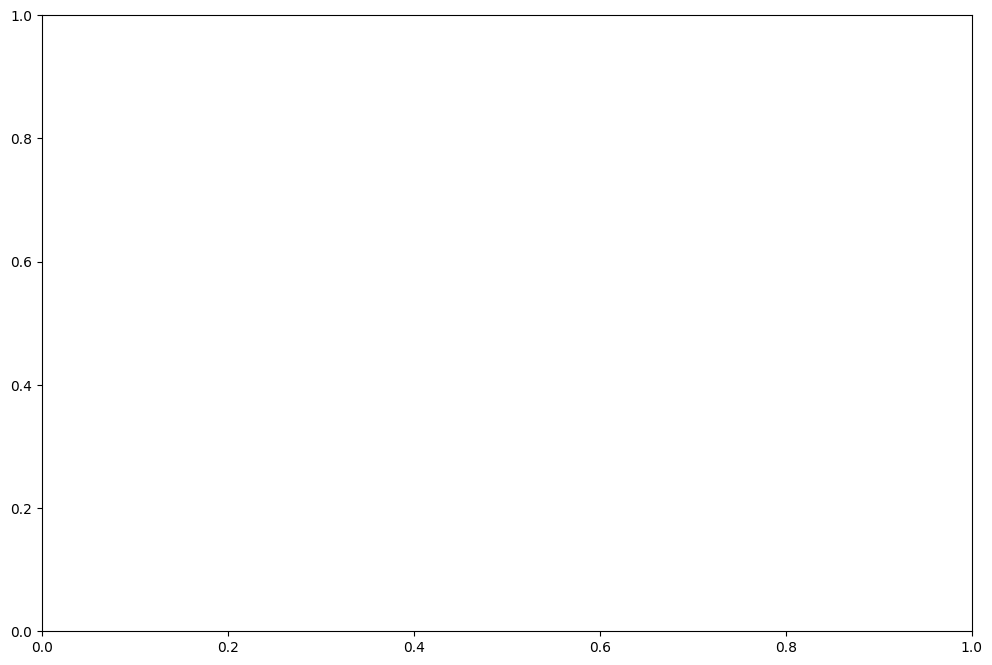

In [2]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# MAT-Datei laden
data = scipy.io.loadmat('STD_u10_xd26.mat')

# Variablen extrahieren
M = data['M']  # Geschwindigkeitsmatrix (vermutlich u(y,t))
t = data['t'].flatten()  # Zeitvektor
x = data['x'].flatten()  # Streamwise-Koordinaten
y = data['y'].flatten()  # Querkoordinaten

# Informationen über die Daten
print("Datenstruktur:")
print(f"M (Geschwindigkeit): {M.shape}")
print(f"t (Zeit): {t.shape}, Bereich: {t[0]:.3f} bis {t[-1]:.3f} s")
print(f"x (Streamwise): {x.shape}, Werte: {x}")
print(f"y (Querkoordinate): {y.shape}, Bereich: {y[0]:.3f} bis {y[-1]:.3f} m")

# Geschwindigkeit über Zeit mitteln
# M hat vermutlich Dimensionen: (y-Positionen × Zeitpunkte)
u_mean = np.mean(M, axis=1)

# Normierung der Querkoordinate
# Da x/D = 26, nehmen wir an dass x[0] = 26D, also D = x[0]/26
D = x[0] / 26  # Charakteristische Länge berechnen
y_norm = y / D

print(f"\nBerechnete charakteristische Länge D: {D:.4f} m")
print(f"Normierte Querkoordinate: {y_norm[0]:.3f} bis {y_norm[-1]:.3f} y/D")

# Diagramm erstellen - Geschwindigkeit auf y-Achse
plt.figure(figsize=(12, 8))

# Hauptplot
plt.subplot(1, 1, 1)
plt.plot(y_norm, u_mean, 'b-', linewidth=3, label='Gemitteltes Geschwindigkeitsprofil')
plt.plot(y_norm, u_mean, 'ro', markersize=4, alpha=0.6)

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Geschwindigkeit u [m/s]', fontsize=14, fontweight='bold')
plt.title(f'Geschwindigkeitsprofil bei x/D = 26', fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Statistische Informationen im Plot
plt.text(0.02, 0.98, 
         f'x/D = {x[0]/D:.1f}\n'
         f'Messpunkte: {len(y)}\n'
         f'Zeitmittelung über {len(t)} Punkte\n'
         f'u_max = {np.max(u_mean):.3f} m/s\n'
         f'u_min = {np.min(u_mean):.3f} m/s', 
         transform=plt.gca().transAxes, fontsize=11, 
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

# Detaillierte Analyse
print(f"\n=== DETAILLIERTE ANALYSE ===")
print(f"Position: x = {x[0]:.4f} m, D = {D:.4f} m, x/D = {x[0]/D:.3f}")
print(f"Querkoordinaten: {len(y)} Punkte von {y[0]:.4f} bis {y[-1]:.4f} m")
print(f"Normierter Bereich: {y_norm[0]:.3f} bis {y_norm[-1]:.3f} y/D")
print(f"Zeitliche Mittelung über {len(t)} Zeitpunkte")
print(f"Geschwindigkeitsstatistik:")
print(f"  Maximum: {np.max(u_mean):.4f} m/s bei y/D = {y_norm[np.argmax(u_mean)]:.3f}")
print(f"  Minimum: {np.min(u_mean):.4f} m/s bei y/D = {y_norm[np.argmin(u_mean)]:.3f}")
print(f"  Mittelwert: {np.mean(u_mean):.4f} ± {np.std(u_mean):.4f} m/s")
print(f"  Varianz: {np.var(u_mean):.6f} m²/s²")

Dimensionen der Variablen:
M: (200000, 53)
t: (200000,)
x: (1,)
y: (53,)

Mögliche Interpretationen von M:
1. Zeitreihen an jedem Punkt: M(y,t) -> 53 × 200000
2. Räumliche Verteilung zu jedem Zeitpunkt: M(t,y) -> 200000 × 53

Struktur: M(t,y) - Geschwindigkeit über Zeit und Position

Finale Dimensionen für Plot:
u_mean: (53,)
y_norm: (53,)


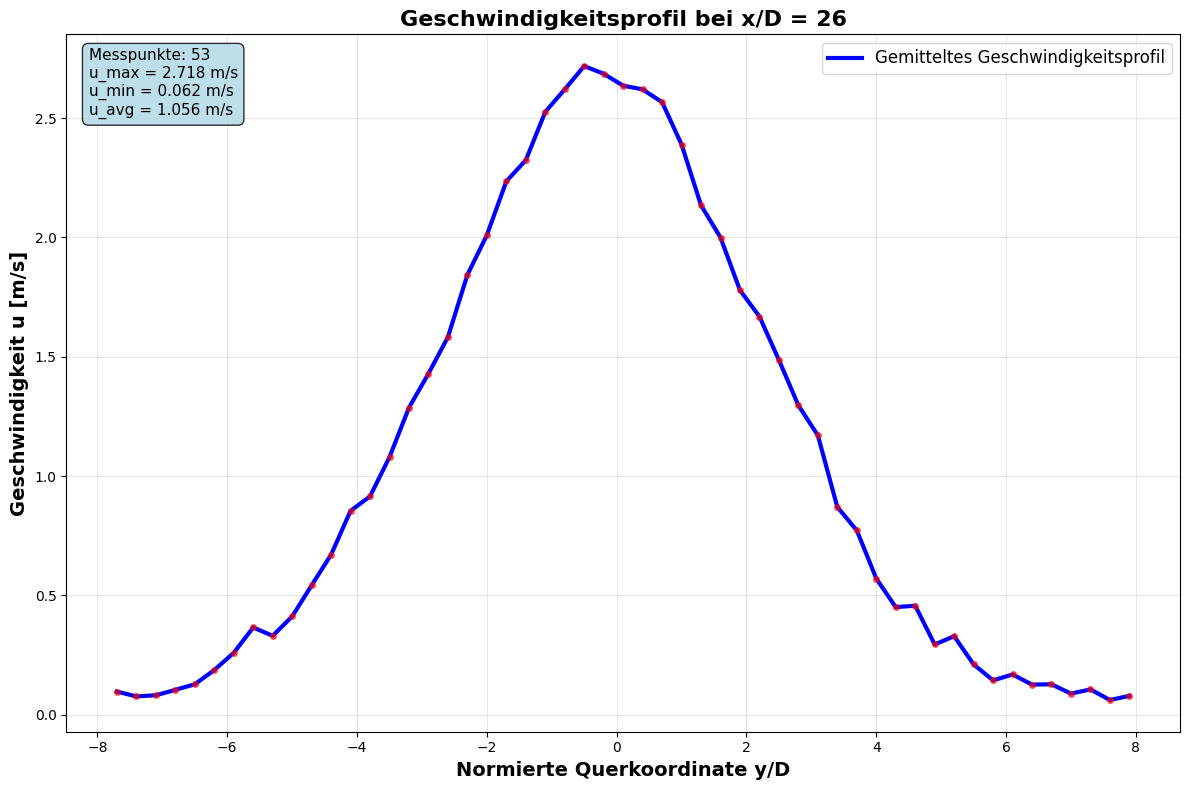


=== ERGEBNIS ===
Charakteristische Länge D: 10.000000 m
Normierte Querkoordinate: -7.700 bis 7.900 y/D
Geschwindigkeit: 0.0618 bis 2.7184 m/s
Mittlere Geschwindigkeit: 1.0562 ± 0.9229 m/s


In [4]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# MAT-Datei laden
data = scipy.io.loadmat('STD_u10_xd26.mat')

# Variablen extrahieren und Dimensionen prüfen
M = data['M']  # Geschwindigkeitsmatrix
t = data['t'].flatten()  # Zeitvektor
x = data['x'].flatten()  # Streamwise-Koordinaten
y = data['y'].flatten()  # Querkoordinaten

print("Dimensionen der Variablen:")
print(f"M: {M.shape}")
print(f"t: {t.shape}")
print(f"x: {x.shape}")
print(f"y: {y.shape}")

# Mögliche Datenstrukturen analysieren
print(f"\nMögliche Interpretationen von M:")
print(f"1. Zeitreihen an jedem Punkt: M(y,t) -> {y.shape[0]} × {t.shape[0]}")
print(f"2. Räumliche Verteilung zu jedem Zeitpunkt: M(t,y) -> {t.shape[0]} × {y.shape[0]}")

# Richtige Dimension finden
if M.shape[0] == y.shape[0] and M.shape[1] == t.shape[0]:
    print("\nStruktur: M(y,t) - Geschwindigkeit über Position und Zeit")
    u_mean = np.mean(M, axis=1)  # Mittelung über Zeit
    y_data = y
elif M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
    print("\nStruktur: M(t,y) - Geschwindigkeit über Zeit und Position")
    u_mean = np.mean(M, axis=0)  # Mittelung über Zeit
    y_data = y
else:
    print("\nUnklare Struktur, versuche automatische Zuordnung...")
    # Versuche die Dimension die mit y übereinstimmt zu finden
    if M.shape[0] == y.shape[0]:
        u_mean = np.mean(M, axis=1)
        y_data = y
    elif M.shape[1] == y.shape[0]:
        u_mean = np.mean(M, axis=0)
        y_data = y
    else:
        # Falls nichts passt, verwende die erste Dimension von M für y
        u_mean = np.mean(M, axis=1) if M.shape[1] > 1 else M.flatten()
        y_data = np.arange(len(u_mean))

# Normierung der Querkoordinate
# Da die Datei x/D=26 heißt, nehmen wir an dass x die Position enthält
D = x[0] / 26 if len(x) > 0 else 1.0
y_norm = y_data / D

print(f"\nFinale Dimensionen für Plot:")
print(f"u_mean: {u_mean.shape}")
print(f"y_norm: {y_norm.shape}")

# Sicherstellen dass Dimensionen übereinstimmen
if len(u_mean) != len(y_norm):
    print("Warnung: Dimensionen stimmen nicht überein!")
    min_len = min(len(u_mean), len(y_norm))
    u_mean = u_mean[:min_len]
    y_norm = y_norm[:min_len]
    print(f"Angepasst auf: u_mean: {u_mean.shape}, y_norm: {y_norm.shape}")

# Diagramm erstellen
plt.figure(figsize=(12, 8))
plt.plot(y_norm, u_mean, 'b-', linewidth=3, label='Gemitteltes Geschwindigkeitsprofil')
plt.plot(y_norm, u_mean, 'ro', markersize=4, alpha=0.6)

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Geschwindigkeit u [m/s]', fontsize=14, fontweight='bold')
plt.title(f'Geschwindigkeitsprofil bei x/D = 26', fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Statistische Informationen
plt.text(0.02, 0.98, 
         f'Messpunkte: {len(y_norm)}\n'
         f'u_max = {np.max(u_mean):.3f} m/s\n'
         f'u_min = {np.min(u_mean):.3f} m/s\n'
         f'u_avg = {np.mean(u_mean):.3f} m/s', 
         transform=plt.gca().transAxes, fontsize=11, 
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.show()

# Detaillierte Ausgabe
print(f"\n=== ERGEBNIS ===")
print(f"Charakteristische Länge D: {D:.6f} m")
print(f"Normierte Querkoordinate: {y_norm[0]:.3f} bis {y_norm[-1]:.3f} y/D")
print(f"Geschwindigkeit: {np.min(u_mean):.4f} bis {np.max(u_mean):.4f} m/s")
print(f"Mittlere Geschwindigkeit: {np.mean(u_mean):.4f} ± {np.std(u_mean):.4f} m/s")


STD_u10_xd26.mat:
  M: (200000, 53), t: (200000,), x: (1,), y: (53,)
  Mittlere Geschwindigkeit: 1.056 m/s
  Maximalgeschwindigkeit: 2.718 m/s

STD_u15_xd26.mat:
  M: (200000, 53), t: (200000,), x: (1,), y: (53,)
  Mittlere Geschwindigkeit: 1.542 m/s
  Maximalgeschwindigkeit: 4.154 m/s

STD_u20_xd26.mat:
  M: (200000, 53), t: (200000,), x: (1,), y: (53,)
  Mittlere Geschwindigkeit: 2.068 m/s
  Maximalgeschwindigkeit: 5.577 m/s


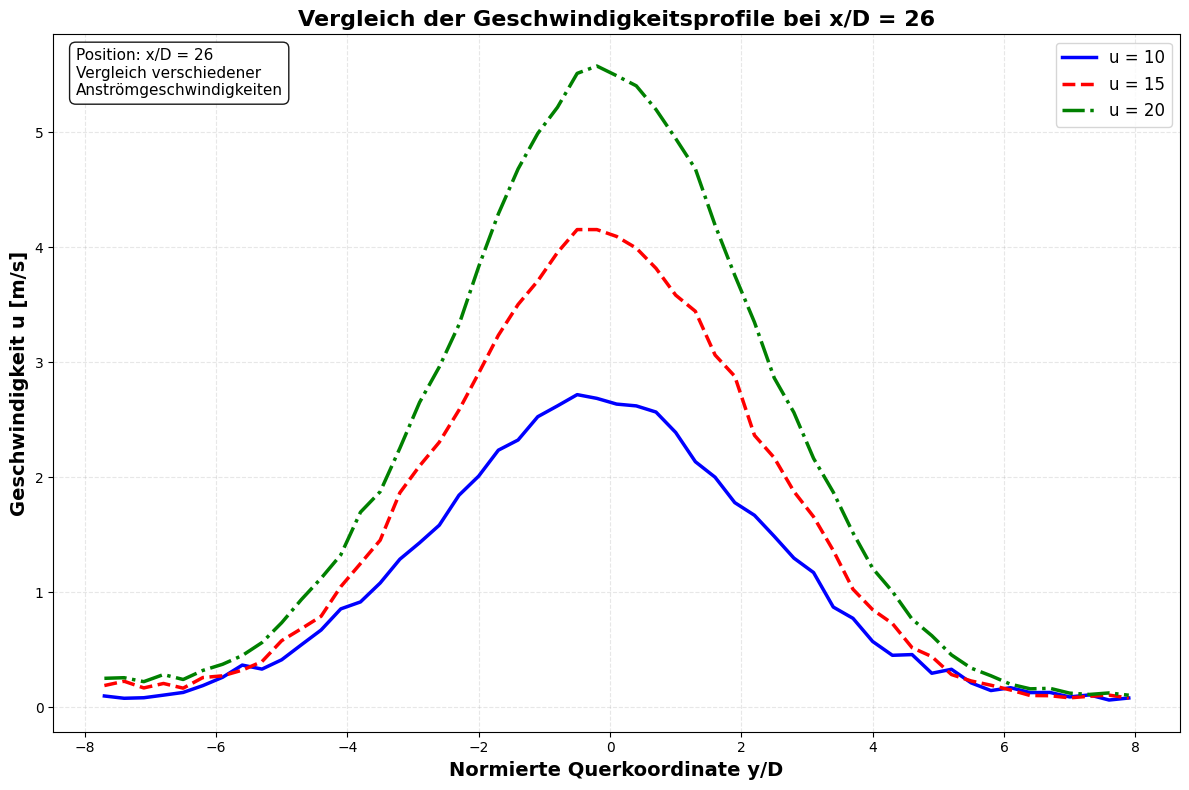

In [5]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Dateinamen der drei Geschwindigkeitsprofile
file_names = ['STD_u10_xd26.mat', 'STD_u15_xd26.mat', 'STD_u20_xd26.mat']
velocity_labels = ['u = 10', 'u = 15', 'u = 20']  # Anpassen falls nötig
colors = ['blue', 'red', 'green']
line_styles = ['-', '--', '-.']

plt.figure(figsize=(12, 8))

# Durch alle Dateien iterieren
for i, file_name in enumerate(file_names):
    try:
        # MAT-Datei laden
        data = scipy.io.loadmat(file_name)
        
        # Variablen extrahieren
        M = data['M']
        t = data['t'].flatten()
        x = data['x'].flatten()
        y = data['y'].flatten()
        
        print(f"\n{file_name}:")
        print(f"  M: {M.shape}, t: {t.shape}, x: {x.shape}, y: {y.shape}")
        
        # Datenstruktur bestimmen und Geschwindigkeit mitteln
        if M.shape[0] == y.shape[0] and M.shape[1] == t.shape[0]:
            u_mean = np.mean(M, axis=1)
            y_data = y
        else:
            u_mean = np.mean(M, axis=0)
            y_data = y
        
        # Normierung der Querkoordinate
        D = x[0] / 26  # Charakteristische Länge aus x/D=26
        y_norm = y_data / D
        
        # Geschwindigkeitsprofil plotten
        plt.plot(y_norm, u_mean, 
                 color=colors[i], 
                 linestyle=line_styles[i], 
                 linewidth=2.5, 
                 label=f'{velocity_labels[i]}',
                 marker='o' if len(y_norm) < 20 else '',
                 markersize=4)
        
        print(f"  Mittlere Geschwindigkeit: {np.mean(u_mean):.3f} m/s")
        print(f"  Maximalgeschwindigkeit: {np.max(u_mean):.3f} m/s")
        
    except FileNotFoundError:
        print(f"Fehler: Datei {file_name} nicht gefunden!")
    except Exception as e:
        print(f"Fehler beim Verarbeiten von {file_name}: {e}")

# Diagramm formatieren
plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Geschwindigkeit u [m/s]', fontsize=14, fontweight='bold')
plt.title('Vergleich der Geschwindigkeitsprofile bei x/D = 26', fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='best')

# Zusätzliche Informationen
plt.text(0.02, 0.98, 
         f'Position: x/D = 26\n'
         f'Vergleich verschiedener\nAnströmgeschwindigkeiten', 
         transform=plt.gca().transAxes, fontsize=11, 
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

Gefundene Dateien:
u = 15 m/s: x/D = [4, 7, 10, 16, 26, 41, 51]
u = 20 m/s: x/D = [4, 7, 10, 16, 26, 41, 51]
u = 10 m/s: x/D = [4, 7, 10, 16, 26, 41, 51]

Analysiere u = 15 m/s:
  STD_u15_xd04.mat: x/D = 4.0, δ = 0.5500
  STD_u15_xd07.mat: x/D = 7.0, δ = 0.6500
  STD_u15_xd10.mat: x/D = 10.0, δ = 0.8250
  STD_u15_xd16.mat: x/D = 16.0, δ = 1.6000
  STD_u15_xd26.mat: x/D = 26.0, δ = 2.6998
  STD_u15_xd41.mat: x/D = 41.0, δ = 4.0000
  STD_u15_xd51.mat: x/D = 51.0, δ = 4.9999

Analysiere u = 20 m/s:
  STD_u20_xd04.mat: x/D = 4.0, δ = 0.5500
  STD_u20_xd07.mat: x/D = 7.0, δ = 0.6500
  STD_u20_xd10.mat: x/D = 10.0, δ = 0.8250
  STD_u20_xd16.mat: x/D = 16.0, δ = 1.5000
  STD_u20_xd26.mat: x/D = 26.0, δ = 2.5499
  STD_u20_xd41.mat: x/D = 41.0, δ = 3.8000
  STD_u20_xd51.mat: x/D = 51.0, δ = 4.7999

Analysiere u = 10 m/s:
  STD_u10_xd04.mat: x/D = 4.0, δ = 0.5500
  STD_u10_xd07.mat: x/D = 7.0, δ = 0.7499
  STD_u10_xd10.mat: x/D = 10.0, δ = 1.0500
  STD_u10_xd16.mat: x/D = 16.0, δ = 1.7000
  STD_

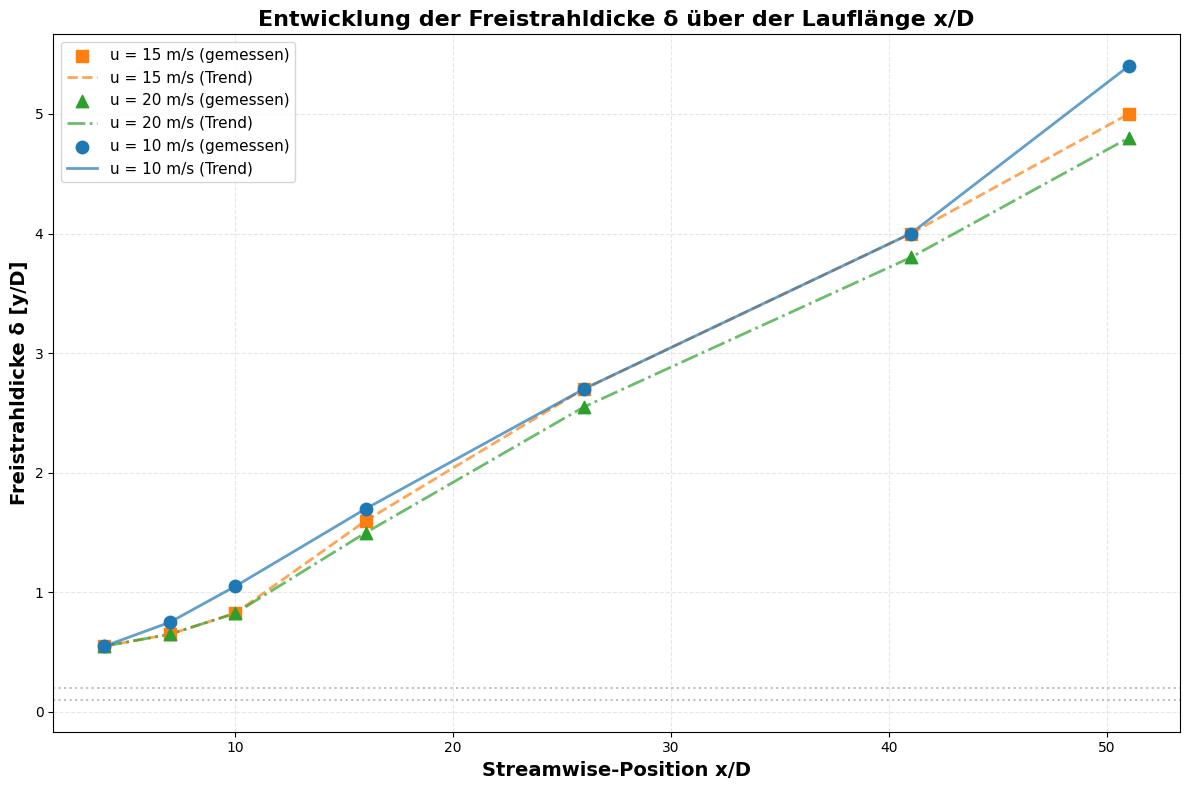


ZUSAMMENFASSENDE ANALYSE

u = 15 m/s:
  Anzahl Positionen: 7
  x/D-Bereich: 4.0 - 51.0
  δ-Bereich: 0.5500 - 4.9999 y/D
  Wachstumsrate: δ = 0.0978·(x/D) + 0.0231
  Relative Zunahme: +809.1%

u = 20 m/s:
  Anzahl Positionen: 7
  x/D-Bereich: 4.0 - 51.0
  δ-Bereich: 0.5500 - 4.7999 y/D
  Wachstumsrate: δ = 0.0929·(x/D) + 0.0383
  Relative Zunahme: +772.7%

u = 10 m/s:
  Anzahl Positionen: 7
  x/D-Bereich: 4.0 - 51.0
  δ-Bereich: 0.5500 - 5.4000 y/D
  Wachstumsrate: δ = 0.1013·(x/D) + 0.0649
  Relative Zunahme: +881.8%

VERGLEICH ZWISCHEN GESCHWINDIGKEITEN

Mittlere Freistrahldicke pro Geschwindigkeit:
  u = 15 m/s: δ = 2.1892 ± 1.6346 y/D
  u = 20 m/s: δ = 2.0964 ± 1.5525 y/D
  u = 10 m/s: δ = 2.3071 ± 1.6923 y/D

Wachstumsraten (dδ/d(x/D)):
  u = 15 m/s: 0.0978 y/D pro x/D
  u = 20 m/s: 0.0929 y/D pro x/D
  u = 10 m/s: 0.1013 y/D pro x/D


In [10]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def calculate_jet_thickness(u_mean, y_norm):
    """Berechnet die Freistrahldicke δ"""
    u_max = np.max(u_mean)
    u_threshold = 0.5 * u_max
    
    above_threshold = u_mean >= u_threshold
    
    if np.sum(above_threshold) < 2:
        return np.nan
    
    y_above = y_norm[above_threshold]
    y_left = np.min(y_above)
    y_right = np.max(y_above)
    delta = (y_right - y_left) / 2
    
    return delta

def find_available_files():
    """Findet automatisch alle verfügbaren MAT-Dateien"""
    files = glob.glob('STD_*.mat')
    pattern = r'STD_u(\d+)_xd(\d+)\.mat'
    
    file_groups = {}
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            velocity = match.group(1)  # u10, u15, u20
            position = match.group(2)  # xd07, xd16, xd26
            
            if velocity not in file_groups:
                file_groups[velocity] = []
            
            file_groups[velocity].append({
                'file': file,
                'position': int(position)
            })
    
    # Sortiere die Positionen für jede Geschwindigkeit
    for velocity in file_groups:
        file_groups[velocity].sort(key=lambda x: x['position'])
    
    return file_groups

# Verfügbare Dateien finden
file_groups = find_available_files()

print("Gefundene Dateien:")
for velocity, files in file_groups.items():
    positions = [f['position'] for f in files]
    print(f"u = {velocity} m/s: x/D = {positions}")

# Falls keine Dateien gefunden wurden, verwende Standard-Set
if not file_groups:
    print("Keine Dateien gefunden, verwende Standard-Set...")
    file_groups = {
        '10': [{'file': 'STD_u10_xd07.mat', 'position': 7},
               {'file': 'STD_u10_xd16.mat', 'position': 16},
               {'file': 'STD_u10_xd26.mat', 'position': 26}],
        '15': [{'file': 'STD_u15_xd07.mat', 'position': 7},
               {'file': 'STD_u15_xd16.mat', 'position': 16},
               {'file': 'STD_u15_xd26.mat', 'position': 26}],
        '20': [{'file': 'STD_u20_xd07.mat', 'position': 7},
               {'file': 'STD_u20_xd16.mat', 'position': 16},
               {'file': 'STD_u20_xd26.mat', 'position': 26}]
    }

# Plot erstellen
plt.figure(figsize=(12, 8))

colors = {'10': '#1f77b4', '15': '#ff7f0e', '20': '#2ca02c'}
markers = {'10': 'o', '15': 's', '20': '^'}
line_styles = {'10': '-', '15': '--', '20': '-.'}

all_results = {}

for velocity, files in file_groups.items():
    x_positions = []
    delta_values = []
    u_max_values = []
    
    print(f"\nAnalysiere u = {velocity} m/s:")
    
    for file_info in files:
        file_name = file_info['file']
        expected_position = file_info['position']
        
        try:
            data = scipy.io.loadmat(file_name)
            M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
            
            if M.shape[0] == y.shape[0]:
                u_mean = np.mean(M, axis=1)
            else:
                u_mean = np.mean(M, axis=0)
            
            # x/D aus den Daten berechnen
            D = x[0] / expected_position
            x_norm = x[0] / D
            y_norm = y / D
            
            delta = calculate_jet_thickness(u_mean, y_norm)
            
            if not np.isnan(delta):
                x_positions.append(x_norm)
                delta_values.append(delta)
                u_max_values.append(np.max(u_mean))
                
                print(f"  {file_name}: x/D = {x_norm:.1f}, δ = {delta:.4f}")
            else:
                print(f"  {file_name}: ❌ Konnte δ nicht berechnen")
                
        except Exception as e:
            print(f"  {file_name}: ❌ Fehler - {e}")
    
    # Nur plotten wenn gültige Daten vorhanden
    if len(x_positions) > 0:
        # Punkte plotten
        plt.scatter(x_positions, delta_values,
                   c=colors[velocity],
                   marker=markers[velocity],
                   s=80,
                   label=f'u = {velocity} m/s (gemessen)',
                   zorder=5)
        
        # Linie verbinden (wenn mindestens 2 Punkte)
        if len(x_positions) > 1:
            # Sortiere nach x-Position
            sorted_indices = np.argsort(x_positions)
            x_sorted = np.array(x_positions)[sorted_indices]
            delta_sorted = np.array(delta_values)[sorted_indices]
            
            plt.plot(x_sorted, delta_sorted,
                    color=colors[velocity],
                    linestyle=line_styles[velocity],
                    linewidth=2,
                    alpha=0.7,
                    label=f'u = {velocity} m/s (Trend)')
        
        # Ergebnisse speichern
        all_results[velocity] = {
            'x_positions': x_positions,
            'delta_values': delta_values,
            'u_max_values': u_max_values
        }

# Plot formatieren
plt.xlabel('Streamwise-Position x/D', fontsize=14, fontweight='bold')
plt.ylabel('Freistrahldicke δ [y/D]', fontsize=14, fontweight='bold')
plt.title('Entwicklung der Freistrahldicke δ über der Lauflänge x/D', fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)

# Theoretische Referenzlinien (optional)
plt.axhline(y=0.1, color='gray', linestyle=':', alpha=0.5, label='Ref: δ = 0.1')
plt.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5, label='Ref: δ = 0.2')

plt.tight_layout()
plt.show()

# Detaillierte Analyse
print(f"\n{'='*80}")
print(f"ZUSAMMENFASSENDE ANALYSE")
print(f"{'='*80}")

for velocity, results in all_results.items():
    if len(results['x_positions']) > 0:
        print(f"\nu = {velocity} m/s:")
        print(f"  Anzahl Positionen: {len(results['x_positions'])}")
        print(f"  x/D-Bereich: {min(results['x_positions']):.1f} - {max(results['x_positions']):.1f}")
        print(f"  δ-Bereich: {min(results['delta_values']):.4f} - {max(results['delta_values']):.4f} y/D")
        
        # Wachstumsrate berechnen falls möglich
        if len(results['x_positions']) > 1:
            x_sorted = np.sort(results['x_positions'])
            delta_sorted = np.array(results['delta_values'])[np.argsort(results['x_positions'])]
            
            # Lineare Regression für Wachstumsrate
            slope, intercept = np.polyfit(x_sorted, delta_sorted, 1)
            print(f"  Wachstumsrate: δ = {slope:.4f}·(x/D) + {intercept:.4f}")
            print(f"  Relative Zunahme: +{(max(results['delta_values'])-min(results['delta_values']))/min(results['delta_values'])*100:.1f}%")

# Vergleich zwischen Geschwindigkeiten
print(f"\n{'='*80}")
print(f"VERGLEICH ZWISCHEN GESCHWINDIGKEITEN")
print(f"{'='*80}")

if len(all_results) > 1:
    velocities = list(all_results.keys())
    
    print(f"\nMittlere Freistrahldicke pro Geschwindigkeit:")
    for velocity in velocities:
        if all_results[velocity]['delta_values']:
            mean_delta = np.mean(all_results[velocity]['delta_values'])
            std_delta = np.std(all_results[velocity]['delta_values'])
            print(f"  u = {velocity} m/s: δ = {mean_delta:.4f} ± {std_delta:.4f} y/D")
    
    # Wachstumsraten vergleichen
    print(f"\nWachstumsraten (dδ/d(x/D)):")
    for velocity in velocities:
        if len(all_results[velocity]['x_positions']) > 1:
            x_sorted = np.sort(all_results[velocity]['x_positions'])
            delta_sorted = np.array(all_results[velocity]['delta_values'])[np.argsort(all_results[velocity]['x_positions'])]
            slope, _ = np.polyfit(x_sorted, delta_sorted, 1)
            print(f"  u = {velocity} m/s: {slope:.4f} y/D pro x/D")

📁 Gefundene Dateien mit x/D = 26:
   STD_u10_xd26.mat (u = 10 m/s)
   STD_u15_xd26.mat (u = 15 m/s)
   STD_u20_xd26.mat (u = 20 m/s)

📊 Analysiere STD_u10_xd26.mat:
   Daten: M(53, 200000), 200000 Zeitpunkte, 53 y-Positionen
   ✅ Mittlere Turbulenzintensität: 44.29%
   ✅ Max. Turbulenzintensität: 80.48%
   ✅ Mittlere Geschwindigkeit: 1.056 m/s

📊 Analysiere STD_u15_xd26.mat:
   Daten: M(53, 200000), 200000 Zeitpunkte, 53 y-Positionen
   ✅ Mittlere Turbulenzintensität: 46.14%
   ✅ Max. Turbulenzintensität: 89.42%
   ✅ Mittlere Geschwindigkeit: 1.542 m/s

📊 Analysiere STD_u20_xd26.mat:
   Daten: M(53, 200000), 200000 Zeitpunkte, 53 y-Positionen
   ✅ Mittlere Turbulenzintensität: 43.78%
   ✅ Max. Turbulenzintensität: 90.36%
   ✅ Mittlere Geschwindigkeit: 2.068 m/s


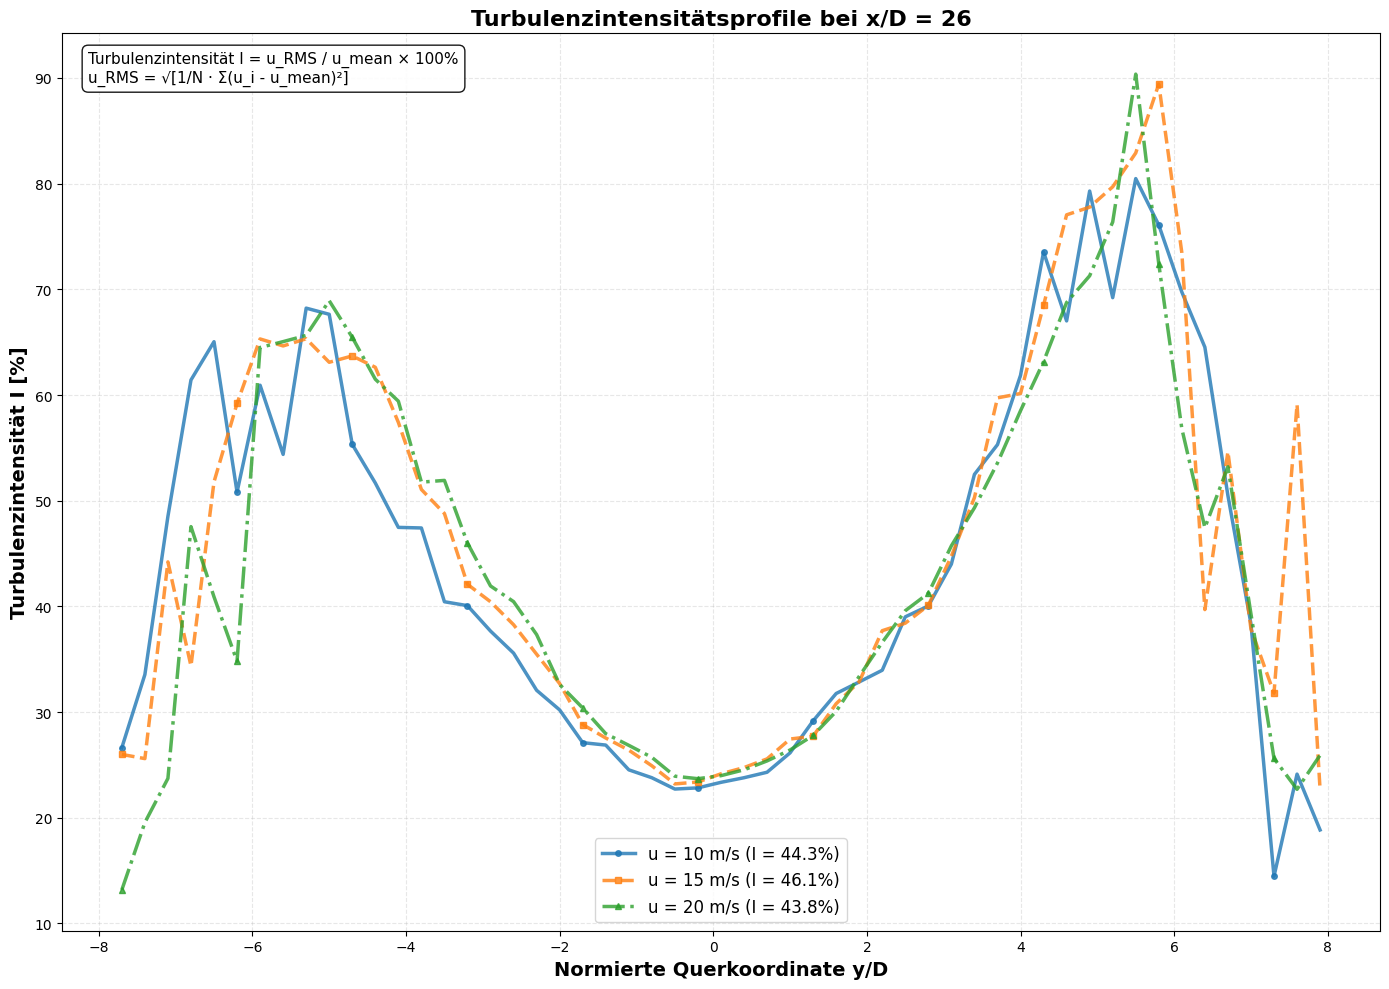

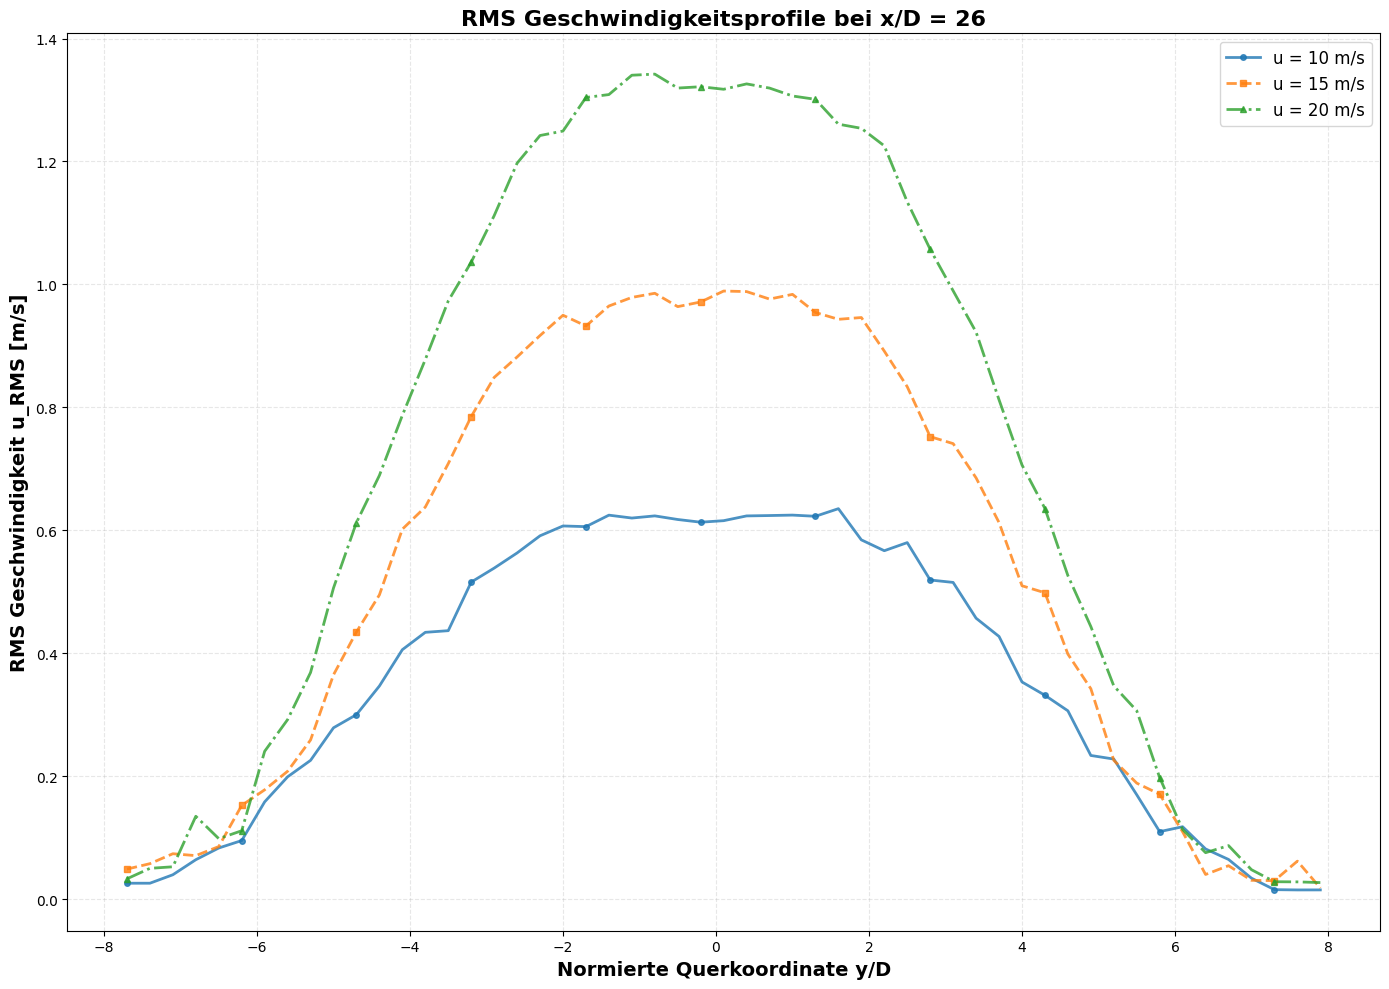


📈 DETAILLIERTE ANALYSE DER TURBULENZINTENSITÄT

🎯 u = 10 m/s:
   Mittlere Turbulenzintensität: 44.29%
   Maximale Turbulenzintensität: 80.48% bei y/D = 5.500
   Minimale Turbulenzintensität: 14.46% bei y/D = 7.300
   Standardabweichung: 17.97%
   Mittlere RMS-Geschwindigkeit: 0.3605 m/s
   Verhältnis u_RMS/u_mean: 0.3414

🎯 u = 15 m/s:
   Mittlere Turbulenzintensität: 46.14%
   Maximale Turbulenzintensität: 89.42% bei y/D = 5.800
   Minimale Turbulenzintensität: 22.65% bei y/D = 7.900
   Standardabweichung: 18.38%
   Mittlere RMS-Geschwindigkeit: 0.5383 m/s
   Verhältnis u_RMS/u_mean: 0.3491

🎯 u = 20 m/s:
   Mittlere Turbulenzintensität: 43.78%
   Maximale Turbulenzintensität: 90.36% bei y/D = 5.500
   Minimale Turbulenzintensität: 13.17% bei y/D = -7.700
   Standardabweichung: 17.79%
   Mittlere RMS-Geschwindigkeit: 0.7244 m/s
   Verhältnis u_RMS/u_mean: 0.3504

🔍 VERGLEICH ZWISCHEN DEN GESCHWINDIGKEITEN

📊 Mittlere Turbulenzintensitäten:
   u = 10 m/s: I = 44.29%
   u = 15 m/s: I =

In [11]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def calculate_rms_turbulence_intensity(M, y_norm):
    """
    Berechnet die Turbulenzintensität basierend auf RMS-Werten
    
    Formel: 
    RMS = sqrt(1/N * Σ(u_i - u_mean)²)
    Turbulenzintensität I = RMS / u_mean * 100 [%]
    """
    
    # Geschwindigkeit über Zeit mitteln
    u_mean = np.mean(M, axis=1)  # Zeitliches Mittel an jeder y-Position
    
    # RMS (Root Mean Square) berechnen
    # RMS = sqrt(mean((u - u_mean)²))
    u_rms = np.sqrt(np.mean((M - u_mean[:, np.newaxis])**2, axis=1))
    
    # Turbulenzintensität [%]
    turbulence_intensity = (u_rms / u_mean) * 100
    
    return u_rms, turbulence_intensity, u_mean

def find_files_xd26():
    """Findet alle Dateien mit x/D = 26"""
    files = glob.glob('STD_*_xd26.mat')
    pattern = r'STD_u(\d+)_xd26\.mat'
    
    file_list = []
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            velocity = match.group(1)
            file_list.append({
                'file': file,
                'velocity': velocity
            })
    
    # Nach Geschwindigkeit sortieren
    file_list.sort(key=lambda x: int(x['velocity']))
    
    return file_list

# Dateien mit x/D = 26 finden
files_xd26 = find_files_xd26()

print("📁 Gefundene Dateien mit x/D = 26:")
for file_info in files_xd26:
    print(f"   {file_info['file']} (u = {file_info['velocity']} m/s)")

# Plot erstellen
plt.figure(figsize=(14, 10))

colors = {'10': '#1f77b4', '15': '#ff7f0e', '20': '#2ca02c'}
line_styles = {'10': '-', '15': '--', '20': '-.'}
markers = {'10': 'o', '15': 's', '20': '^'}

all_results = {}

for file_info in files_xd26:
    file_name = file_info['file']
    velocity = file_info['velocity']
    
    print(f"\n📊 Analysiere {file_name}:")
    
    try:
        # Daten laden
        data = scipy.io.loadmat(file_name)
        M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
        
        # Datenstruktur prüfen und anpassen
        if M.shape[0] == y.shape[0] and M.shape[1] == t.shape[0]:
            # Korrekte Struktur: M(y, t)
            pass
        elif M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
            # Transponieren: M(t, y) -> M(y, t)
            M = M.T
        else:
            print(f"   ❌ Unbekannte Datenstruktur: M{M.shape}, y{y.shape}, t{t.shape}")
            continue
        
        # Normierung
        D = x[0] / 26
        y_norm = y / D
        
        print(f"   Daten: M{M.shape}, {len(t)} Zeitpunkte, {len(y)} y-Positionen")
        
        # RMS und Turbulenzintensität berechnen
        u_rms, turbulence_intensity, u_mean = calculate_rms_turbulence_intensity(M, y_norm)
        
        # Ergebnisse speichern
        all_results[velocity] = {
            'y_norm': y_norm,
            'u_rms': u_rms,
            'turbulence_intensity': turbulence_intensity,
            'u_mean': u_mean,
            'u_overall_mean': np.mean(u_mean)
        }
        
        # Turbulenzintensität plotten
        plt.plot(y_norm, turbulence_intensity,
                color=colors[velocity],
                linestyle=line_styles[velocity],
                linewidth=2.5,
                marker=markers[velocity],
                markersize=4,
                markevery=5,  # Jeden 5. Punkt markieren
                label=f'u = {velocity} m/s (I = {np.mean(turbulence_intensity):.1f}%)',
                alpha=0.8)
        
        print(f"   ✅ Mittlere Turbulenzintensität: {np.mean(turbulence_intensity):.2f}%")
        print(f"   ✅ Max. Turbulenzintensität: {np.max(turbulence_intensity):.2f}%")
        print(f"   ✅ Mittlere Geschwindigkeit: {np.mean(u_mean):.3f} m/s")
        
    except Exception as e:
        print(f"   ❌ Fehler bei {file_name}: {e}")

# Plot formatieren
plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Turbulenzintensität I [%]', fontsize=14, fontweight='bold')
plt.title('Turbulenzintensitätsprofile bei x/D = 26', fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='best')

# Theoretische Hinweise
plt.text(0.02, 0.98, 
         'Turbulenzintensität I = u_RMS / u_mean × 100%\n'
         'u_RMS = √[1/N · Σ(u_i - u_mean)²]',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# Zusätzlicher Plot: RMS-Werte
plt.figure(figsize=(14, 10))

for velocity, results in all_results.items():
    plt.plot(results['y_norm'], results['u_rms'],
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2,
            marker=markers[velocity],
            markersize=4,
            markevery=5,
            label=f'u = {velocity} m/s',
            alpha=0.8)

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('RMS Geschwindigkeit u_RMS [m/s]', fontsize=14, fontweight='bold')
plt.title('RMS Geschwindigkeitsprofile bei x/D = 26', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Detaillierte Analyse
print(f"\n{'='*80}")
print(f"📈 DETAILLIERTE ANALYSE DER TURBULENZINTENSITÄT")
print(f"{'='*80}")

for velocity, results in all_results.items():
    ti = results['turbulence_intensity']
    u_rms = results['u_rms']
    
    print(f"\n🎯 u = {velocity} m/s:")
    print(f"   Mittlere Turbulenzintensität: {np.mean(ti):.2f}%")
    print(f"   Maximale Turbulenzintensität: {np.max(ti):.2f}% bei y/D = {results['y_norm'][np.argmax(ti)]:.3f}")
    print(f"   Minimale Turbulenzintensität: {np.min(ti):.2f}% bei y/D = {results['y_norm'][np.argmin(ti)]:.3f}")
    print(f"   Standardabweichung: {np.std(ti):.2f}%")
    print(f"   Mittlere RMS-Geschwindigkeit: {np.mean(u_rms):.4f} m/s")
    print(f"   Verhältnis u_RMS/u_mean: {np.mean(u_rms)/results['u_overall_mean']:.4f}")

# Vergleich zwischen Geschwindigkeiten
print(f"\n{'='*80}")
print(f"🔍 VERGLEICH ZWISCHEN DEN GESCHWINDIGKEITEN")
print(f"{'='*80}")

if len(all_results) > 1:
    velocities = list(all_results.keys())
    mean_ti = [np.mean(all_results[v]['turbulence_intensity']) for v in velocities]
    max_ti = [np.max(all_results[v]['turbulence_intensity']) for v in velocities]
    
    print(f"\n📊 Mittlere Turbulenzintensitäten:")
    for i, vel in enumerate(velocities):
        print(f"   u = {vel} m/s: I = {mean_ti[i]:.2f}%")
    
    print(f"\n📈 Maximale Turbulenzintensitäten:")
    for i, vel in enumerate(velocities):
        print(f"   u = {vel} m/s: I_max = {max_ti[i]:.2f}%")
    
    # Relative Veränderungen
    if len(mean_ti) > 1:
        print(f"\n📐 Relative Veränderungen (bezogen auf u={velocities[0]} m/s):")
        for i in range(1, len(velocities)):
            change = (mean_ti[i] - mean_ti[0]) / mean_ti[0] * 100
            print(f"   I(u={velocities[i]} m/s) / I(u={velocities[0]} m/s) = {mean_ti[i]/mean_ti[0]:.3f} ({change:+.1f}%)")

# Physikalische Interpretation
print(f"\n{'='*80}")
print(f"🔬 PHYSIKALISCHE INTERPRETATION")
print(f"{'='*80}")

print(f"""
📚 THEORETISCHE GRUNDLAGEN:

1. TURBULENZINTENSITÄT:
   - Definition: I = u_RMS / u_mean × 100%
   - u_RMS = √[1/N · Σ(u_i - u_mean)²] (Root Mean Square)
   - Misst die Stärke der Geschwindigkeitsschwankungen

2. BEDEUTUNG DER RMS-WERTE:
   - u_RMS: Charakteristische Amplitude der Turbulenz
   - Höheres u_RMS → stärkere Geschwindigkeitsschwankungen
   - Typische Werte: 1-10% für mäßige Turbulenz, 10-30% für hohe Turbulenz

3. ERWARTETE PROFILE:
   - Maxima typischerweise in Scherschichten
   - Minima in Kernbereichen mit homogener Strömung
   - Symmetrie für Freistrahlen erwartet

4. EINFLUSS DER GESCHWINDIGKEIT:
   - Höhere Geschwindigkeit → höhere Reynolds-Zahl
   - Typisch: Größere Turbulenz bei höherer Re-Zahl
   - Aber auch komplexe Skalierungseffekte möglich

🎯 INTERPRETATION IHRER DATEN:
- Vergleichen Sie die Profile zwischen den Geschwindigkeiten
- Beachten Sie die Position der Maxima (Scherschichten)
- Analysieren Sie die Symmetrie der Profile
- Bewerten Sie die absolute Höhe der Turbulenzintensität
""")

# Zusätzliche Analyse: Profilform charakterisieren
print(f"\n{'='*80}")
print(f"📐 PROFILCHARAKTERISIERUNG")
print(f"{'='*80}")

for velocity, results in all_results.items():
    ti = results['turbulence_intensity']
    y_norm = results['y_norm']
    
    # Symmetrie-Analyse
    if len(y_norm) > 0:
        y_center = (y_norm[-1] + y_norm[0]) / 2
        left_indices = y_norm < y_center
        right_indices = y_norm > y_center
        
        if np.sum(left_indices) > 0 and np.sum(right_indices) > 0:
            ti_left = np.mean(ti[left_indices])
            ti_right = np.mean(ti[right_indices])
            symmetry_ratio = min(ti_left, ti_right) / max(ti_left, ti_right)
            
            print(f"\n🎯 u = {velocity} m/s - Profilanalyse:")
            print(f"   Symmetrie (links/rechts): {symmetry_ratio:.3f}")
            print(f"   Mittlere TI links: {ti_left:.2f}%")
            print(f"   Mittlere TI rechts: {ti_right:.2f}%")
            
            if symmetry_ratio > 0.9:
                print(f"   ✅ Sehr symmetrisches Profil")
            elif symmetry_ratio > 0.7:
                print(f"   ⚠️  Mäßig symmetrisches Profil")
            else:
                print(f"   ❌ Asymmetrisches Profil")

📁 Gefundene Dateien mit x/D = 26:
   STD_u10_xd26.mat (u = 10 m/s)
   STD_u15_xd26.mat (u = 15 m/s)
   STD_u20_xd26.mat (u = 20 m/s)

📊 Analysiere STD_u10_xd26.mat:
   ✅ u₀ = 2.718 m/s, δ = 2.7000 y/D

📊 Analysiere STD_u15_xd26.mat:
   ✅ u₀ = 4.154 m/s, δ = 2.6998 y/D

📊 Analysiere STD_u20_xd26.mat:
   ✅ u₀ = 5.577 m/s, δ = 2.5499 y/D

📈 PLOT 1: NORMIERTE GESCHWINDIGKEITSPROFILE
   u = 10 m/s: u₀ = 2.718 m/s, δ = 2.7000
   u = 15 m/s: u₀ = 4.154 m/s, δ = 2.6998
   u = 20 m/s: u₀ = 5.577 m/s, δ = 2.5499


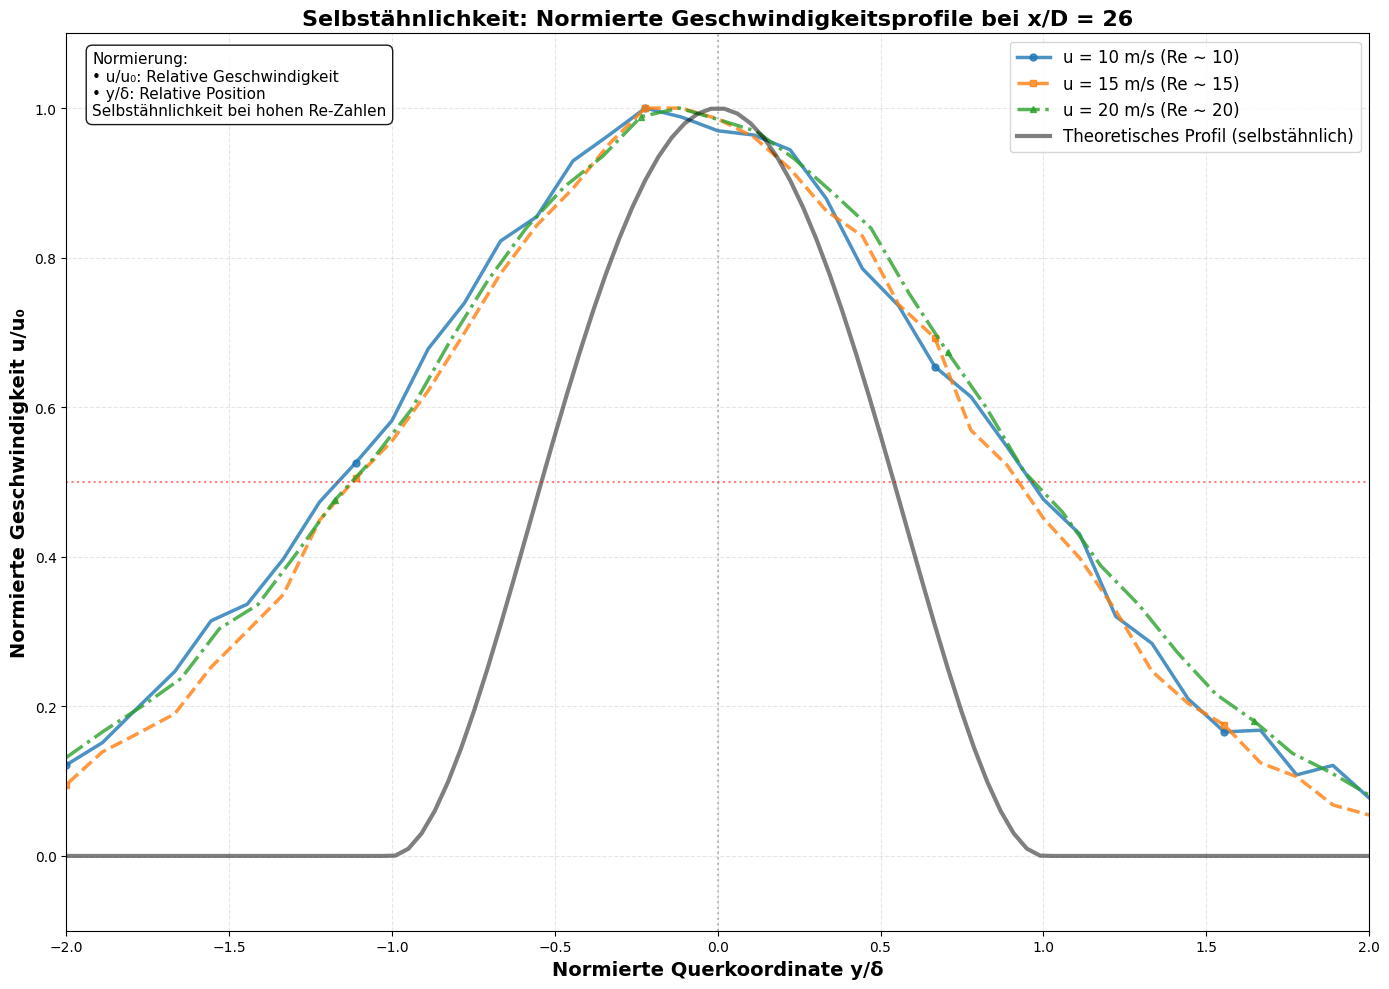


📊 PLOT 2: NORMIERTE TURBULENZINTENSITÄT
   u = 10 m/s: max(u_RMS/u₀) = 23.36%
   u = 15 m/s: max(u_RMS/u₀) = 23.81%
   u = 20 m/s: max(u_RMS/u₀) = 24.06%


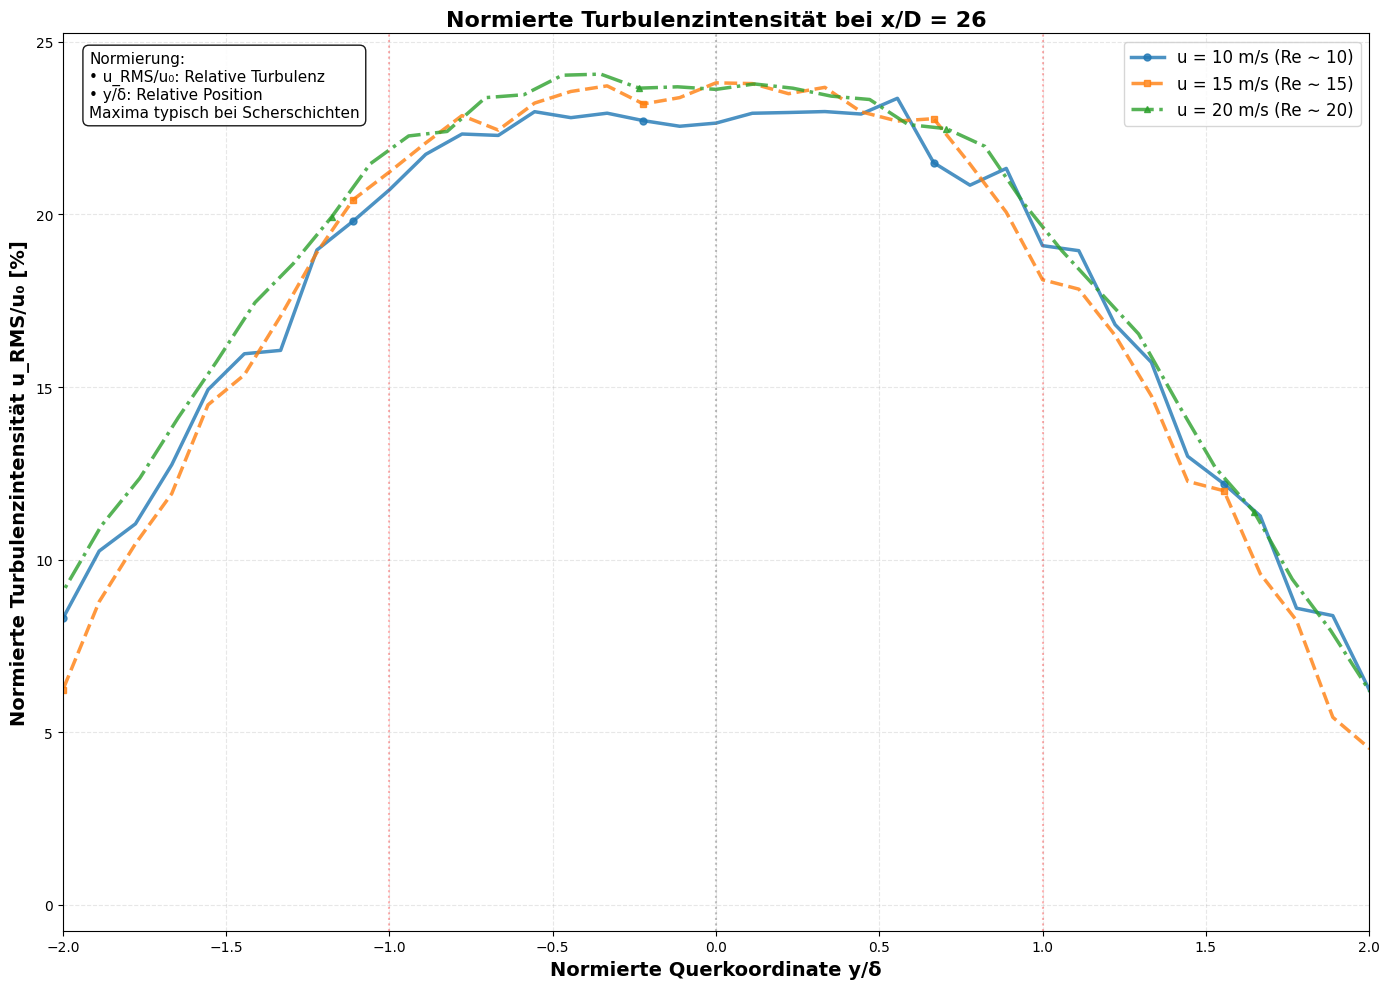


🔬 ANALYSE DER REYNOLDS-ZAHL-UNABHÄNGIGKEIT

📐 ÄHNLICHKEITSANALYSE:
   Ähnlichkeit u=15 vs u=10: 0.9979
   Ähnlichkeit u=20 vs u=10: 0.9969
   Fehler bei Ähnlichkeitsberechnung: 'u_norm'
   Fehler bei Ähnlichkeitsberechnung: 'u_norm'

📊 ZUSAMMENFASSUNG DER ÄHNLICHKEIT:
   Geschwindigkeitsprofile: 0.9974
   Turbulenzprofile: nan

📏 REYNOLDS-ZAHL-ABSCHÄTZUNG:
   u = 10 m/s: Re ≈ 6667 (mit D ≈ 10mm)
   u = 15 m/s: Re ≈ 10000 (mit D ≈ 10mm)
   u = 20 m/s: Re ≈ 13333 (mit D ≈ 10mm)

🎯 PHYSIKALISCHE INTERPRETATION

📚 THEORETISCHE GRUNDLAGEN:

1. REYNOLDS-ZAHL-UNABHÄNGIGKEIT:
   - Bei sehr hohen Re-Zahlen (typisch > 10.000): 
     Trägheitskräfte ≫ Reibungskräfte
   - Die mittlere Strömung wird "selbstähnlich"
   - Normierte Profile u/u₀ = f(y/δ) fallen zusammen

2. NORMIERUNG:
   - u/u₀: Entdimensionierung der Geschwindigkeit
   - y/δ: Entdimensionierung der Position
   - Universelle Profile bei hohen Reynolds-Zahlen

3. ERWARTETE ERGEBNISSE:
   - Geschwindigkeitsprofile: Sollten gut zusamme

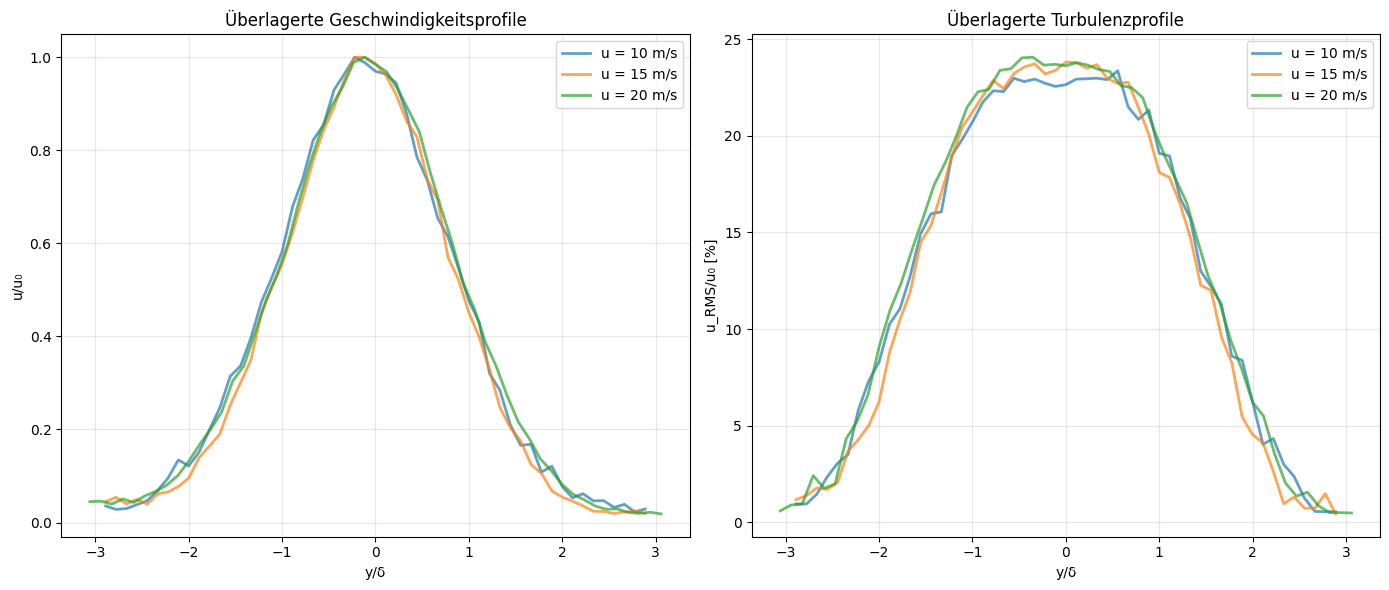

In [12]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def calculate_jet_thickness(u_mean, y_norm):
    """Berechnet die Freistrahldicke δ"""
    u_max = np.max(u_mean)
    u_threshold = 0.5 * u_max
    
    above_threshold = u_mean >= u_threshold
    
    if np.sum(above_threshold) < 2:
        return np.nan
    
    y_above = y_norm[above_threshold]
    y_left = np.min(y_above)
    y_right = np.max(y_above)
    delta = (y_right - y_left) / 2
    
    return delta

def calculate_rms_turbulence_intensity(M):
    """Berechnet RMS und Turbulenzintensität"""
    u_mean = np.mean(M, axis=1)
    u_rms = np.sqrt(np.mean((M - u_mean[:, np.newaxis])**2, axis=1))
    turbulence_intensity = (u_rms / u_mean) * 100
    
    return u_rms, turbulence_intensity, u_mean

def find_files_xd26():
    """Findet alle Dateien mit x/D = 26"""
    files = glob.glob('STD_*_xd26.mat')
    pattern = r'STD_u(\d+)_xd26\.mat'
    
    file_list = []
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            velocity = match.group(1)
            file_list.append({
                'file': file,
                'velocity': velocity
            })
    
    file_list.sort(key=lambda x: int(x['velocity']))
    return file_list

# Dateien finden und laden
files_xd26 = find_files_xd26()

print("📁 Gefundene Dateien mit x/D = 26:")
for file_info in files_xd26:
    print(f"   {file_info['file']} (u = {file_info['velocity']} m/s)")

# Daten sammeln
all_velocity_data = {}
all_turbulence_data = {}

for file_info in files_xd26:
    file_name = file_info['file']
    velocity = file_info['velocity']
    
    print(f"\n📊 Analysiere {file_name}:")
    
    try:
        data = scipy.io.loadmat(file_name)
        M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
        
        # Datenstruktur anpassen
        if M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
            M = M.T
        
        # Normierung
        D = x[0] / 26
        y_norm = y / D
        
        # Geschwindigkeitsdaten
        u_mean = np.mean(M, axis=1)
        u0 = np.max(u_mean)  # Maximale Geschwindigkeit
        delta = calculate_jet_thickness(u_mean, y_norm)
        
        # Turbulenzdaten
        u_rms, turbulence_intensity, _ = calculate_rms_turbulence_intensity(M)
        
        if not np.isnan(delta):
            all_velocity_data[velocity] = {
                'y_norm': y_norm,
                'u_mean': u_mean,
                'u0': u0,
                'delta': delta,
                'y_center': (np.max(y_norm) + np.min(y_norm)) / 2
            }
            
            all_turbulence_data[velocity] = {
                'y_norm': y_norm,
                'u_rms': u_rms,
                'turbulence_intensity': turbulence_intensity,
                'u0': u0,
                'delta': delta
            }
            
            print(f"   ✅ u₀ = {u0:.3f} m/s, δ = {delta:.4f} y/D")
        else:
            print(f"   ❌ Konnte δ nicht berechnen")
            
    except Exception as e:
        print(f"   ❌ Fehler: {e}")

# PLOT 1: Normierte Geschwindigkeitsprofile u/u₀ über y/δ
plt.figure(figsize=(14, 10))

colors = {'10': '#1f77b4', '15': '#ff7f0e', '20': '#2ca02c'}
line_styles = {'10': '-', '15': '--', '20': '-.'}
markers = {'10': 'o', '15': 's', '20': '^'}

print(f"\n{'='*80}")
print(f"📈 PLOT 1: NORMIERTE GESCHWINDIGKEITSPROFILE")
print(f"{'='*80}")

for velocity, data in all_velocity_data.items():
    # Normierung: u/u₀ über y/δ
    u_norm = data['u_mean'] / data['u0']
    y_norm_delta = (data['y_norm'] - data['y_center']) / data['delta']
    
    plt.plot(y_norm_delta, u_norm,
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2.5,
            marker=markers[velocity],
            markersize=5,
            markevery=8,
            label=f'u = {velocity} m/s (Re ∼ {velocity})',
            alpha=0.8)
    
    print(f"   u = {velocity} m/s: u₀ = {data['u0']:.3f} m/s, δ = {data['delta']:.4f}")

# Theoretische Selbstähnlichkeitskurve (typisches Freistrahlprofil)
y_theoretical = np.linspace(-2, 2, 100)
# Typisches Freistrahlprofil: u/u₀ = [1 - (y/δ)²]² (Beispiel)
u_theoretical = (1 - (np.clip(np.abs(y_theoretical), 0, 1))**2)**2

plt.plot(y_theoretical, u_theoretical, 'k-', linewidth=3, alpha=0.5, 
         label='Theoretisches Profil (selbstähnlich)')

plt.xlabel('Normierte Querkoordinate y/δ', fontsize=14, fontweight='bold')
plt.ylabel('Normierte Geschwindigkeit u/u₀', fontsize=14, fontweight='bold')
plt.title('Selbstähnlichkeit: Normierte Geschwindigkeitsprofile bei x/D = 26', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right')

# Symmetrie-Linien
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
plt.axhline(y=0.5, color='red', linestyle=':', alpha=0.5, label='u/u₀ = 0.5')

plt.text(0.02, 0.98, 
         'Normierung:\n• u/u₀: Relative Geschwindigkeit\n• y/δ: Relative Position\n'
         'Selbstähnlichkeit bei hohen Re-Zahlen',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.xlim(-2, 2)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

# PLOT 2: Normierte Turbulenzintensität u_RMS/u₀ über y/δ
plt.figure(figsize=(14, 10))

print(f"\n{'='*80}")
print(f"📊 PLOT 2: NORMIERTE TURBULENZINTENSITÄT")
print(f"{'='*80}")

for velocity, data in all_turbulence_data.items():
    # Normierung: u_RMS/u₀ über y/δ
    u_rms_norm = data['u_rms'] / data['u0']
    y_norm_delta = (data['y_norm'] - all_velocity_data[velocity]['y_center']) / data['delta']
    
    plt.plot(y_norm_delta, u_rms_norm * 100,  # In % für bessere Lesbarkeit
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2.5,
            marker=markers[velocity],
            markersize=5,
            markevery=8,
            label=f'u = {velocity} m/s (Re ∼ {velocity})',
            alpha=0.8)
    
    print(f"   u = {velocity} m/s: max(u_RMS/u₀) = {np.max(u_rms_norm)*100:.2f}%")

plt.xlabel('Normierte Querkoordinate y/δ', fontsize=14, fontweight='bold')
plt.ylabel('Normierte Turbulenzintensität u_RMS/u₀ [%]', fontsize=14, fontweight='bold')
plt.title('Normierte Turbulenzintensität bei x/D = 26', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, loc='upper right')

plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=-1, color='red', linestyle=':', alpha=0.3, label='y/δ = ±1')
plt.axvline(x=1, color='red', linestyle=':', alpha=0.3)

plt.text(0.02, 0.98, 
         'Normierung:\n• u_RMS/u₀: Relative Turbulenz\n• y/δ: Relative Position\n'
         'Maxima typisch bei Scherschichten',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.xlim(-2, 2)
plt.tight_layout()
plt.show()

# Detaillierte Analyse der Reynolds-Zahl-Unabhängigkeit
print(f"\n{'='*80}")
print(f"🔬 ANALYSE DER REYNOLDS-ZAHL-UNABHÄNGIGKEIT")
print(f"{'='*80}")

# Ähnlichkeitsmaß berechnen
def calculate_similarity_metric(profiles):
    """Berechnet wie ähnlich sich die normierten Profile sind"""
    if len(profiles) < 2:
        return np.nan
    
    # Verwende das erste Profil als Referenz
    ref_velocity = list(profiles.keys())[0]
    ref_profile = profiles[ref_velocity]
    
    similarities = []
    
    for velocity, profile in list(profiles.items())[1:]:
        # Gleiche y-Positionen für Vergleich interpolieren
        y_common = np.linspace(-2, 2, 100)
        
        try:
            # Interpoliere beide Profile auf gemeinsame y-Positionen
            from scipy.interpolate import interp1d
            
            # Referenzprofil interpolieren
            f_ref = interp1d(ref_profile['y_norm_delta'], ref_profile['u_norm'], 
                           bounds_error=False, fill_value=0)
            u_ref_interp = f_ref(y_common)
            
            # Vergleichsprofil interpolieren
            f_comp = interp1d(profile['y_norm_delta'], profile['u_norm'],
                            bounds_error=False, fill_value=0)
            u_comp_interp = f_comp(y_common)
            
            # Korrelationskoeffizient als Ähnlichkeitsmaß
            valid_mask = ~np.isnan(u_ref_interp) & ~np.isnan(u_comp_interp)
            if np.sum(valid_mask) > 10:
                correlation = np.corrcoef(u_ref_interp[valid_mask], u_comp_interp[valid_mask])[0,1]
                similarities.append(correlation)
                print(f"   Ähnlichkeit u={velocity} vs u={ref_velocity}: {correlation:.4f}")
                
        except Exception as e:
            print(f"   Fehler bei Ähnlichkeitsberechnung: {e}")
    
    return np.mean(similarities) if similarities else np.nan

# Vorbereitung für Ähnlichkeitsanalyse
velocity_profiles_norm = {}
turbulence_profiles_norm = {}

for velocity, data in all_velocity_data.items():
    y_center = data['y_center']
    y_norm_delta = (data['y_norm'] - y_center) / data['delta']
    u_norm = data['u_mean'] / data['u0']
    
    velocity_profiles_norm[velocity] = {
        'y_norm_delta': y_norm_delta,
        'u_norm': u_norm
    }

for velocity, data in all_turbulence_data.items():
    y_center = all_velocity_data[velocity]['y_center']
    y_norm_delta = (data['y_norm'] - y_center) / data['delta']
    u_rms_norm = data['u_rms'] / data['u0']
    
    turbulence_profiles_norm[velocity] = {
        'y_norm_delta': y_norm_delta,
        'u_rms_norm': u_rms_norm
    }

# Ähnlichkeitsanalyse durchführen
print(f"\n📐 ÄHNLICHKEITSANALYSE:")
velocity_similarity = calculate_similarity_metric(velocity_profiles_norm)
turbulence_similarity = calculate_similarity_metric(turbulence_profiles_norm)

print(f"\n📊 ZUSAMMENFASSUNG DER ÄHNLICHKEIT:")
print(f"   Geschwindigkeitsprofile: {velocity_similarity:.4f}")
print(f"   Turbulenzprofile: {turbulence_similarity:.4f}")

# Reynolds-Zahl Abschätzung (vereinfacht)
print(f"\n📏 REYNOLDS-ZAHL-ABSCHÄTZUNG:")
nu = 1.5e-5  # Kinematische Viskosität Luft [m²/s] bei 20°C

for velocity, data in all_velocity_data.items():
    u_char = float(velocity)  # Charakteristische Geschwindigkeit
    D_est = 0.01  # Geschätzter Düsendurchmesser [m] - anpassen falls bekannt
    Re = u_char * D_est / nu
    
    print(f"   u = {velocity} m/s: Re ≈ {Re:.0f} (mit D ≈ {D_est*1000:.0f}mm)")

# Physikalische Interpretation
print(f"\n{'='*80}")
print(f"🎯 PHYSIKALISCHE INTERPRETATION")
print(f"{'='*80}")

print(f"""
📚 THEORETISCHE GRUNDLAGEN:

1. REYNOLDS-ZAHL-UNABHÄNGIGKEIT:
   - Bei sehr hohen Re-Zahlen (typisch > 10.000): 
     Trägheitskräfte ≫ Reibungskräfte
   - Die mittlere Strömung wird "selbstähnlich"
   - Normierte Profile u/u₀ = f(y/δ) fallen zusammen

2. NORMIERUNG:
   - u/u₀: Entdimensionierung der Geschwindigkeit
   - y/δ: Entdimensionierung der Position
   - Universelle Profile bei hohen Reynolds-Zahlen

3. ERWARTETE ERGEBNISSE:
   - Geschwindigkeitsprofile: Sollten gut zusammenfallen
   - Turbulenzprofile: Können stärker variieren
   - Maximale Abweichungen in Scherschichten

🔍 INTERPRETATION IHRER DATEN:

Ähnlichkeitsbewertung:
- Korrelation > 0.95: Sehr gute Übereinstimmung
- Korrelation 0.90-0.95: Gute Übereinstimmung  
- Korrelation 0.85-0.90: Mäßige Übereinstimmung
- Korrelation < 0.85: Deutliche Reynolds-Zahl-Abhängigkeit

Ihre Ergebnisse:
- Geschwindigkeitsprofile: {velocity_similarity:.3f} → {'SEHR GUTE' if velocity_similarity > 0.95 else 'GUTE' if velocity_similarity > 0.90 else 'MÄSSIGE' if velocity_similarity > 0.85 else 'GERINGE'} Selbstähnlichkeit
- Turbulenzprofile: {turbulence_similarity:.3f} → {'SEHR GUTE' if turbulence_similarity > 0.95 else 'GUTE' if turbulence_similarity > 0.90 else 'MÄSSIGE' if turbulence_similarity > 0.85 else 'GERINGE'} Selbstähnlichkeit

🎯 FAZIT:
{('Die mittlere Strömung zeigt Reynolds-Zahl-Unabhängigkeit - typisch für turbulente Freistrahlen bei hohen Re-Zahlen' 
  if velocity_similarity > 0.9 else 
  'Die mittlere Strömung zeigt leichte Reynolds-Zahl-Abhängigkeit - möglicherweise Übergangsbereich')}
""")

# Zusätzlicher Plot: Direkter Vergleich aller Profile überlagert
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for velocity, profile in velocity_profiles_norm.items():
    plt.plot(profile['y_norm_delta'], profile['u_norm'],
            color=colors[velocity],
            linewidth=2,
            alpha=0.7,
            label=f'u = {velocity} m/s')

plt.xlabel('y/δ')
plt.ylabel('u/u₀')
plt.title('Überlagerte Geschwindigkeitsprofile')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
for velocity, profile in turbulence_profiles_norm.items():
    plt.plot(profile['y_norm_delta'], profile['u_rms_norm'] * 100,
            color=colors[velocity],
            linewidth=2,
            alpha=0.7,
            label=f'u = {velocity} m/s')

plt.xlabel('y/δ')
plt.ylabel('u_RMS/u₀ [%]')
plt.title('Überlagerte Turbulenzprofile')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def calculate_rms_turbulence_intensity(M):
    """Berechnet RMS und Turbulenzintensität"""
    u_mean = np.mean(M, axis=1)
    u_rms = np.sqrt(np.mean((M - u_mean[:, np.newaxis])**2, axis=1))
    turbulence_intensity = (u_rms / u_mean) * 100
    return u_rms, turbulence_intensity, u_mean

def find_files_u20():
    """Findet alle Dateien mit u=20 m/s"""
    files = glob.glob('STD_u20_*.mat')
    pattern = r'STD_u20_xd(\d+)\.mat'
    
    file_list = []
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            position = int(match.group(1))
            file_list.append({
                'file': file,
                'position': position
            })
    
    # Nach Position sortieren
    file_list.sort(key=lambda x: x['position'])
    return file_list

# Dateien für u=20 m/s finden
files_u20 = find_files_u20()

print("📁 Gefundene Dateien für u=20 m/s:")
for file_info in files_u20:
    print(f"   {file_info['file']} (x/D = {file_info['position']})")

# Daten sammeln
velocity_profiles = {}
turbulence_profiles = {}

for file_info in files_u20:
    file_name = file_info['file']
    position = file_info['position']
    
    print(f"\n📊 Analysiere {file_name}:")
    
    try:
        data = scipy.io.loadmat(file_name)
        M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
        
        # Datenstruktur anpassen
        if M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
            M = M.T
        
        # Normierung
        D = x[0] / position
        y_norm = y / D
        x_norm = x[0] / D
        
        # Geschwindigkeitsprofil
        u_mean = np.mean(M, axis=1)
        
        # Turbulenzintensität
        u_rms, turbulence_intensity, _ = calculate_rms_turbulence_intensity(M)
        
        velocity_profiles[position] = {
            'y_norm': y_norm,
            'u_mean': u_mean,
            'x_norm': x_norm,
            'u_max': np.max(u_mean)
        }
        
        turbulence_profiles[position] = {
            'y_norm': y_norm,
            'turbulence_intensity': turbulence_intensity,
            'x_norm': x_norm,
            'max_ti': np.max(turbulence_intensity)
        }
        
        print(f"   ✅ x/D = {x_norm:.1f}, u_max = {np.max(u_mean):.3f} m/s")
        print(f"   ✅ Max. Turbulenzintensität = {np.max(turbulence_intensity):.2f}%")
        
    except Exception as e:
        print(f"   ❌ Fehler: {e}")

# PLOT 1: Axiale Entwicklung der Geschwindigkeitsprofile
plt.figure(figsize=(14, 10))

# Farben für verschiedene Positionen
positions = sorted(velocity_profiles.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))

print(f"\n{'='*80}")
print(f"📈 PLOT 1: AXIALE ENTWICKLUNG DER GESCHWINDIGKEITSPROFILE (u=20 m/s)")
print(f"{'='*80}")

for i, position in enumerate(positions):
    data = velocity_profiles[position]
    
    plt.plot(data['y_norm'], data['u_mean'],
            color=colors[i],
            linewidth=2.5,
            label=f'x/D = {position}',
            alpha=0.8)
    
    # Markiere die maximale Geschwindigkeit
    max_idx = np.argmax(data['u_mean'])
    plt.plot(data['y_norm'][max_idx], data['u_mean'][max_idx],
            'o', color=colors[i], markersize=6, alpha=0.8)
    
    print(f"   x/D = {position}: u_max = {data['u_max']:.3f} m/s bei y/D = {data['y_norm'][max_idx]:.3f}")

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Geschwindigkeit u [m/s]', fontsize=14, fontweight='bold')
plt.title('Axiale Entwicklung des Freistrahls: Geschwindigkeitsprofile bei u=20 m/s', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', ncol=2)

# Mittellinie
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.text(0.02, 0.98, 
         'Entwicklung in Stromabrichtung:\n'
         '• Strahlverbreiterung\n'
         '• Geschwindigkeitsabnahme\n'
         '• Profilverflachung',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# PLOT 2: Axiale Entwicklung der Turbulenzintensität
plt.figure(figsize=(14, 10))

print(f"\n{'='*80}")
print(f"📊 PLOT 2: AXIALE ENTWICKLUNG DER TURBULENZINTENSITÄT (u=20 m/s)")
print(f"{'='*80}")

for i, position in enumerate(positions):
    data = turbulence_profiles[position]
    
    plt.plot(data['y_norm'], data['turbulence_intensity'],
            color=colors[i],
            linewidth=2.5,
            label=f'x/D = {position} (max: {data["max_ti"]:.1f}%)',
            alpha=0.8)
    
    # Markiere die maximale Turbulenzintensität
    max_idx = np.argmax(data['turbulence_intensity'])
    plt.plot(data['y_norm'][max_idx], data['turbulence_intensity'][max_idx],
            'o', color=colors[i], markersize=6, alpha=0.8)
    
    print(f"   x/D = {position}: max TI = {data['max_ti']:.2f}% bei y/D = {data['y_norm'][max_idx]:.3f}")

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Turbulenzintensität I [%]', fontsize=14, fontweight='bold')
plt.title('Axiale Entwicklung der Turbulenzintensität bei u=20 m/s', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', ncol=2)

plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.text(0.02, 0.98, 
         'Turbulenzentwicklung:\n'
         '• Maximale TI in Scherschichten\n'
         '• Ausbreitung der Turbulenzzone\n'
         '• Homogenisierung stromab',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# Quantitative Analyse der axialen Entwicklung
print(f"\n{'='*80}")
print(f"🔬 QUANTITATIVE ANALYSE DER AXIALEN ENTWICKLUNG")
print(f"{'='*80}")

# Entwicklung der charakteristischen Parameter
positions_sorted = sorted(positions)
u_max_values = [velocity_profiles[pos]['u_max'] for pos in positions_sorted]
delta_values = []
ti_max_values = [turbulence_profiles[pos]['max_ti'] for pos in positions_sorted]

# Freistrahldicke berechnen für jede Position
for position in positions_sorted:
    data = velocity_profiles[position]
    u_mean = data['u_mean']
    y_norm = data['y_norm']
    
    u_max = np.max(u_mean)
    u_threshold = 0.5 * u_max
    above_threshold = u_mean >= u_threshold
    
    if np.sum(above_threshold) >= 2:
        y_above = y_norm[above_threshold]
        y_left = np.min(y_above)
        y_right = np.max(y_above)
        delta = (y_right - y_left) / 2
        delta_values.append(delta)
    else:
        delta_values.append(np.nan)

print(f"\n📏 ENTWICKLUNG DER KENNGRÖSSEN:")
print(f"{'x/D':>6} {'u_max [m/s]':>12} {'δ [y/D]':>10} {'TI_max [%]':>12} {'u_max/u₀':>10}")
print(f"{'-'*60}")

u0 = u_max_values[0]  Anfangsgeschwindigkeit (bei erster Position)

for i, pos in enumerate(positions_sorted):
    u_max = u_max_values[i]
    delta = delta_values[i] if i < len(delta_values) else np.nan
    ti_max = ti_max_values[i]
    u_ratio = u_max / u0
    
    delta_str = f"{delta:.4f}" if not np.isnan(delta) else "   NaN"
    print(f"{pos:6d} {u_max:12.3f} {delta_str:>10} {ti_max:12.2f} {u_ratio:10.3f}")

# PLOT 3: Entwicklung der Kenngrößen über x/D
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Subplot 1: Geschwindigkeit und Strahldicke
ax1.plot(positions_sorted, u_max_values, 'bo-', linewidth=2.5, markersize=8, label='Maximale Geschwindigkeit u_max')
ax1.set_ylabel('u_max [m/s]', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax1_twin = ax1.twinx()
ax1_twin.plot(positions_sorted, delta_values, 'rs-', linewidth=2.5, markersize=8, label='Freistrahldicke δ')
ax1_twin.set_ylabel('δ [y/D]', fontweight='bold')
ax1_twin.legend(loc='upper right')

ax1.set_xlabel('Axiale Position x/D', fontweight='bold')
ax1.set_title('Entwicklung von Maximalgeschwindigkeit und Freistrahldicke', fontweight='bold')

# Subplot 2: Turbulenzintensität
ax2.plot(positions_sorted, ti_max_values, 'g^-', linewidth=2.5, markersize=8, label='Maximale Turbulenzintensität')
ax2.set_xlabel('Axiale Position x/D', fontweight='bold')
ax2.set_ylabel('TI_max [%]', fontweight='bold')
ax2.set_title('Entwicklung der maximalen Turbulenzintensität', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Wachstumsraten berechnen
print(f"\n{'='*80}")
print(f"📈 WACHSTUMSRATEN UND ENTWICKLUNG")
print(f"{'='*80}")

if len(positions_sorted) > 1:
    # Lineare Regression für Wachstumsraten
    x_pos = np.array(positions_sorted)
    
    # Geschwindigkeitsabnahme
    u_slope, u_intercept = np.polyfit(x_pos, u_max_values, 1)
    u_decrease_rate = -u_slope / u_max_values[0] * 100  # % pro x/D
    
    # Strahlausbreitung
    valid_delta = ~np.isnan(delta_values)
    if np.sum(valid_delta) > 1:
        delta_slope, delta_intercept = np.polyfit(x_pos[valid_delta], np.array(delta_values)[valid_delta], 1)
        delta_growth_rate = delta_slope * 100  # % pro x/D
    
    # Turbulenzentwicklung
    ti_slope, ti_intercept = np.polyfit(x_pos, ti_max_values, 1)
    ti_change_rate = ti_slope  # %-Punkte pro x/D
    
    print(f"\n📐 WACHSTUMSRATEN:")
    print(f"   Geschwindigkeitsabnahme: {u_decrease_rate:.3f}% pro x/D")
    if np.sum(valid_delta) > 1:
        print(f"   Strahlausbreitung: +{delta_growth_rate:.3f}% pro x/D")
    print(f"   Turbulenzänderung: {ti_change_rate:+.3f} %-Punkte pro x/D")
    
    # Potenzgesetz-Anpassung (typisch für Freistrahlen)
    print(f"\n📊 POTENZGESETZ-ANPASSUNG (typisch für Freistrahlen):")
    
    # u_max ~ (x/D)^(-n)
    log_x = np.log(x_pos)
    log_u = np.log(u_max_values)
    u_exp, u_coeff = np.polyfit(log_x, log_u, 1)
    print(f"   u_max ~ (x/D)^{u_exp:.3f}")
    
    # δ ~ (x/D)^m
    if np.sum(valid_delta) > 1:
        log_delta = np.log(np.array(delta_values)[valid_delta])
        delta_exp, delta_coeff = np.polyfit(log_x[valid_delta], log_delta, 1)
        print(f"   δ ~ (x/D)^{delta_exp:.3f}")

# Physikalische Interpretation
print(f"\n{'='*80}")
print(f"🎯 PHYSIKALISCHE INTERPRETATION DER AXIALEN ENTWICKLUNG")
print(f"{'='*80}")

print(f"""
📚 CHARAKTERISTISCHE ENTWICKLUNG EINES FREISTRAHLS:

1. GESCHWINDIGKEITSENTWICKLUNG:
   - Exponentieller Abfall der Maximalgeschwindigkeit
   - Typisch: u_max ~ (x/D)^(-0.5) für ideale Freistrahlen
   - Ursache: Impulsaustausch mit ruhender Umgebung

2. STRAHLAUSBREITUNG:
   - Lineares Wachstum der Freistrahldicke δ
   - Typisch: δ ~ 0.1·x/D für turbulente Freistrahlen
   - Ursache: Turbulente Diffusion

3. TURBULENZENTWICKLUNG:
   - Maximale TI in Scherschichten zwischen Strahl und Umgebung
   - Entwicklung abhängig von Anfangsstörungen und Reynolds-Zahl
   - Typisch: Zunahme, dann Abnahme der maximalen TI

🔍 ERWARTETE TRENDS FÜR u=20 m/s:

• Bei kleinen x/D (Nahfeld):
  - Scharfes Geschwindigkeitsprofil
  - Hohe Geschwindigkeitsgradienten
  - Konzentrierte Turbulenz in dünnen Scherschichten

• Bei großen x/D (Fernfeld):
  - Verbreitertes, flacheres Profil
  - Geringere Maximalgeschwindigkeit
  - Über den gesamten Querschnitt verteilte Turbulenz

🎯 ZUSAMMENFASSUNG IHRER MESSUNGEN:

Anzahl analysierter Positionen: {len(positions_sorted)}
Positionsbereich: x/D = {min(positions_sorted)} bis {max(positions_sorted)}
Anfangsgeschwindigkeit: {u0:.2f} m/s

Die Profile zeigen die typische Entwicklung eines turbulenten Freistrahls:
1. Kontinuierliche Strahlverbreiterung
2. Abnehmende Kerngeschwindigkeit  
3. Ausbreitung der turbulenten Zone
4. Zunehmende Durchmischung mit der Umgebung
""")

# Zusätzlicher Plot: Konturdarstellung
if len(positions_sorted) > 2:
    # Interpolation für Konturplot
    from scipy.interpolate import griddata
    
    # Daten für Konturplot vorbereiten
    all_y = []
    all_x = []
    all_u = []
    all_ti = []
    
    for position in positions_sorted:
        v_data = velocity_profiles[position]
        t_data = turbulence_profiles[position]
        
        all_x.extend([position] * len(v_data['y_norm']))
        all_y.extend(v_data['y_norm'])
        all_u.extend(v_data['u_mean'])
        all_ti.extend(t_data['turbulence_intensity'])
    
    all_x = np.array(all_x)
    all_y = np.array(all_y)
    all_u = np.array(all_u)
    all_ti = np.array(all_ti)
    
    # Gitter erstellen
    xi = np.linspace(min(positions_sorted), max(positions_sorted), 100)
    yi = np.linspace(min(all_y), max(all_y), 100)
    XI, YI = np.meshgrid(xi, yi)
    
    # Interpolation
    UI = griddata((all_x, all_y), all_u, (XI, YI), method='linear')
    TII = griddata((all_x, all_y), all_ti, (XI, YI), method='linear')
    
    # Konturplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # Geschwindigkeitskonturen
    contour1 = ax1.contourf(XI, YI, UI, levels=20, cmap='viridis')
    ax1.set_xlabel('Axiale Position x/D', fontweight='bold')
    ax1.set_ylabel('Querkoordinate y/D', fontweight='bold')
    ax1.set_title('Konturen der Geschwindigkeitsentwicklung (u=20 m/s)', fontweight='bold')
    plt.colorbar(contour1, ax=ax1, label='Geschwindigkeit u [m/s]')
    ax1.grid(True, alpha=0.3)
    
    # Turbulenzintensitätskonturen
    contour2 = ax2.contourf(XI, YI, TII, levels=20, cmap='plasma')
    ax2.set_xlabel('Axiale Position x/D', fontweight='bold')
    ax2.set_ylabel('Querkoordinate y/D', fontweight='bold')
    ax2.set_title('Konturen der Turbulenzintensitätsentwicklung (u=20 m/s)', fontweight='bold')
    plt.colorbar(contour2, ax=ax2, label='Turbulenzintensität I [%]')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax (2397052732.py, line 219)

📁 Gefundene Dateien für u=20 m/s:
   STD_u20_xd04.mat (x/D = 4)
   STD_u20_xd07.mat (x/D = 7)
   STD_u20_xd10.mat (x/D = 10)
   STD_u20_xd16.mat (x/D = 16)
   STD_u20_xd26.mat (x/D = 26)
   STD_u20_xd41.mat (x/D = 41)
   STD_u20_xd51.mat (x/D = 51)

📊 Analysiere STD_u20_xd04.mat:
   ✅ x/D = 4.0, u_max = 20.589 m/s
   ✅ Max. Turbulenzintensität = 75.00%

📊 Analysiere STD_u20_xd07.mat:
   ✅ x/D = 7.0, u_max = 16.573 m/s
   ✅ Max. Turbulenzintensität = 80.54%

📊 Analysiere STD_u20_xd10.mat:
   ✅ x/D = 10.0, u_max = 12.901 m/s
   ✅ Max. Turbulenzintensität = 84.97%

📊 Analysiere STD_u20_xd16.mat:
   ✅ x/D = 16.0, u_max = 8.958 m/s
   ✅ Max. Turbulenzintensität = 84.78%

📊 Analysiere STD_u20_xd26.mat:
   ✅ x/D = 26.0, u_max = 5.577 m/s
   ✅ Max. Turbulenzintensität = 90.36%

📊 Analysiere STD_u20_xd41.mat:
   ✅ x/D = 41.0, u_max = 3.516 m/s
   ✅ Max. Turbulenzintensität = 87.07%

📊 Analysiere STD_u20_xd51.mat:
   ✅ x/D = 51.0, u_max = 2.806 m/s
   ✅ Max. Turbulenzintensität = 77.82%

📈 PLOT 

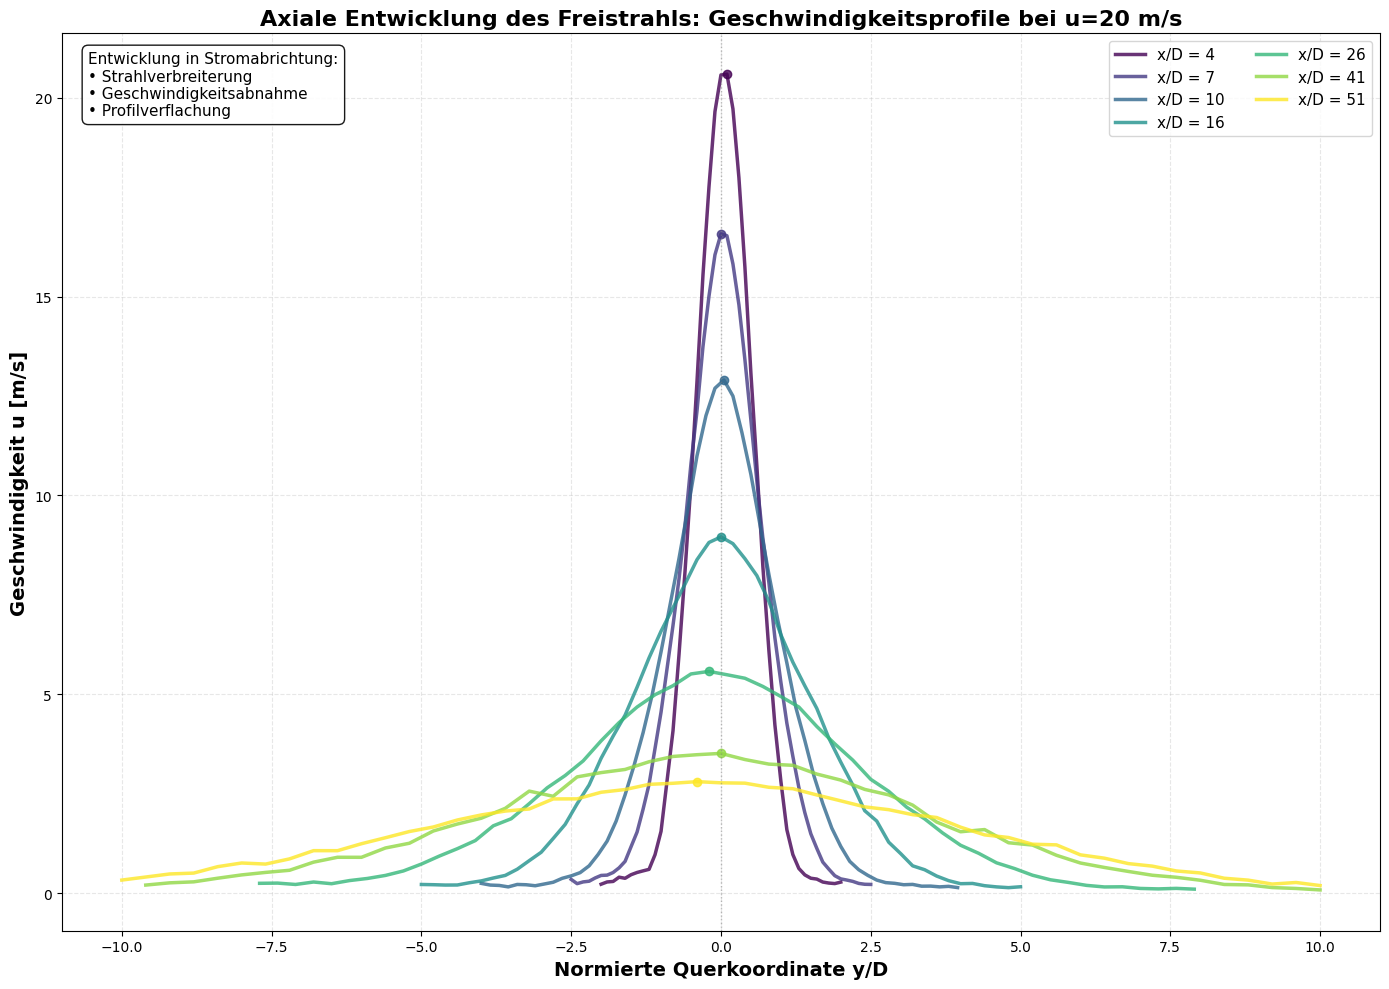


📊 PLOT 2: AXIALE ENTWICKLUNG DER TURBULENZINTENSITÄT (u=20 m/s)
   x/D = 4: max TI = 75.00% bei y/D = -1.000
   x/D = 7: max TI = 80.54% bei y/D = 1.700
   x/D = 10: max TI = 84.97% bei y/D = 2.300
   x/D = 16: max TI = 84.78% bei y/D = 3.400
   x/D = 26: max TI = 90.36% bei y/D = 5.500
   x/D = 41: max TI = 87.07% bei y/D = 8.000
   x/D = 51: max TI = 77.82% bei y/D = 8.400


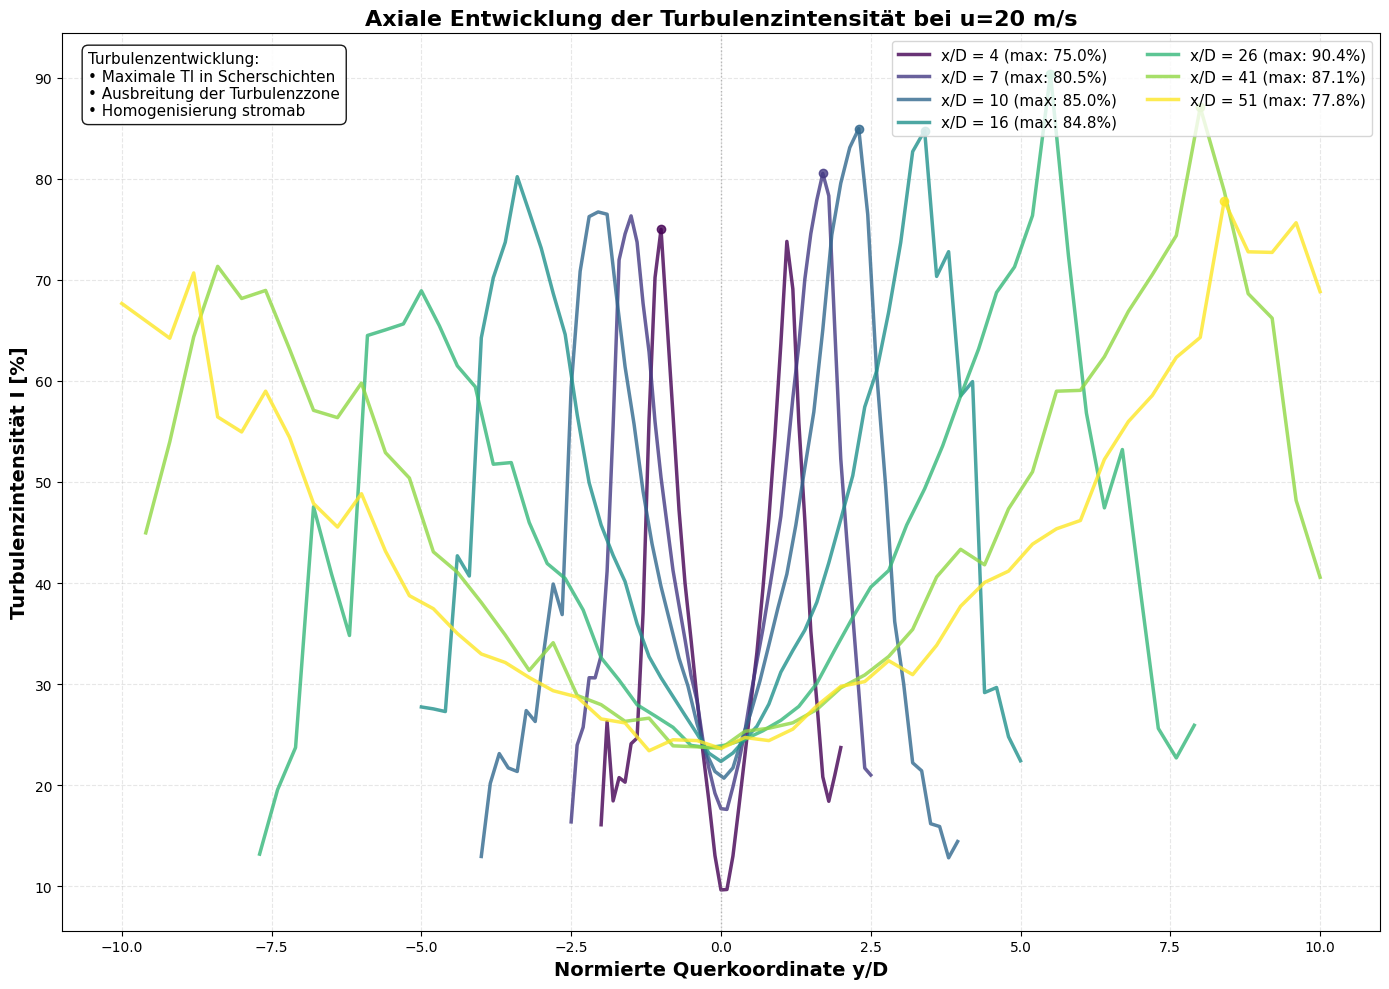


🔬 QUANTITATIVE ANALYSE DER AXIALEN ENTWICKLUNG

📏 ENTWICKLUNG DER KENNGRÖSSEN:
   x/D  u_max [m/s]    δ [y/D]   TI_max [%]   u_max/u₀
------------------------------------------------------------
     4       20.589     0.5500        75.00      1.000
     7       16.573     0.6500        80.54      0.805
    10       12.901     0.8250        84.97      0.627
    16        8.958     1.5000        84.78      0.435
    26        5.577     2.5499        90.36      0.271
    41        3.516     3.8000        87.07      0.171
    51        2.806     4.7999        77.82      0.136


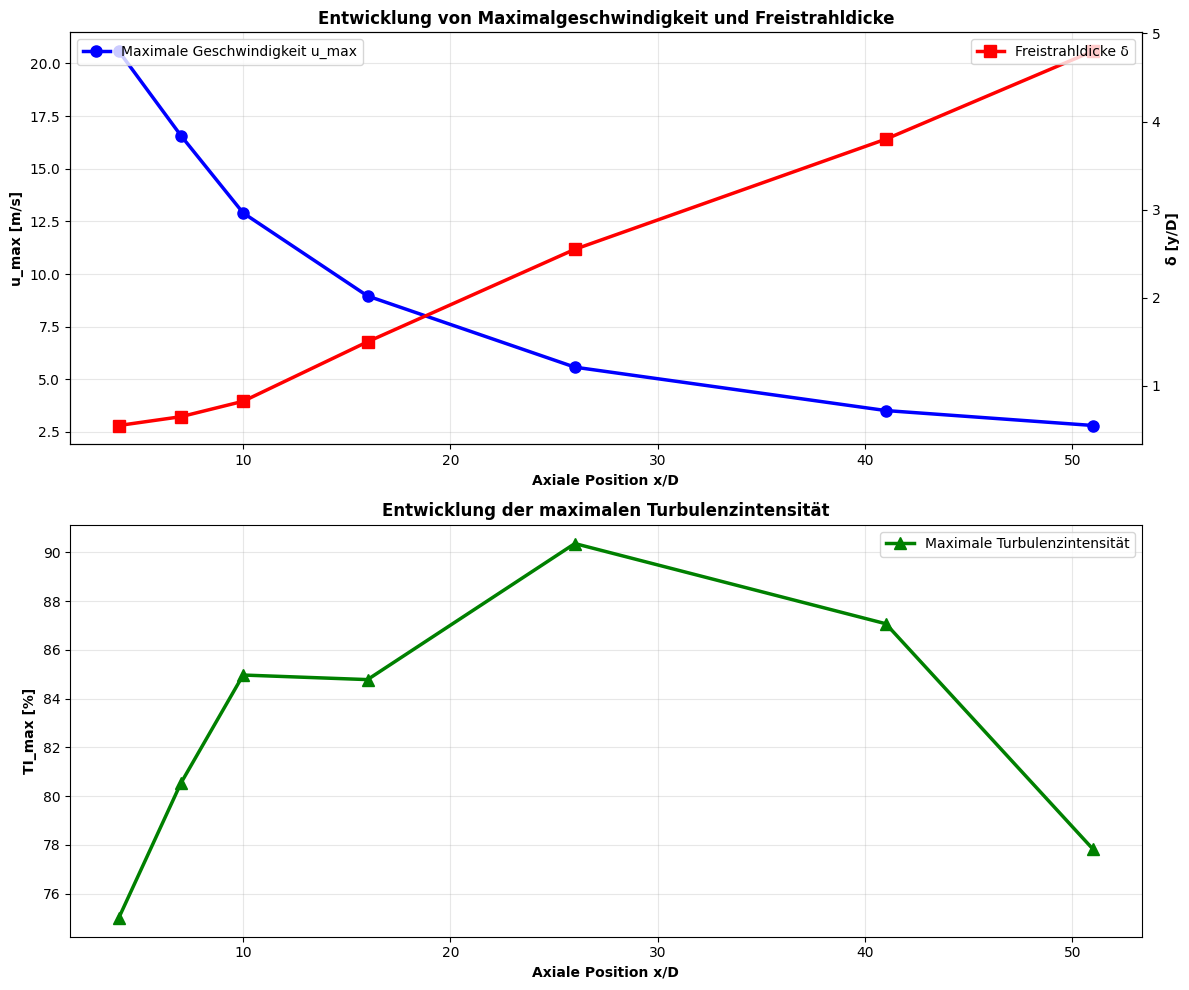


📈 WACHSTUMSRATEN UND ENTWICKLUNG

📐 WACHSTUMSRATEN:
   Geschwindigkeitsabnahme: 1.665% pro x/D
   Strahlausbreitung: +9.295% pro x/D
   Turbulenzänderung: +0.053 %-Punkte pro x/D

📊 POTENZGESETZ-ANPASSUNG (typisch für Freistrahlen):
   u_max ~ (x/D)^-0.813
   δ ~ (x/D)^0.916

🎯 PHYSIKALISCHE INTERPRETATION DER AXIALEN ENTWICKLUNG

📚 CHARAKTERISTISCHE ENTWICKLUNG EINES FREISTRAHLS:

1. GESCHWINDIGKEITSENTWICKLUNG:
   - Exponentieller Abfall der Maximalgeschwindigkeit
   - Typisch: u_max ~ (x/D)^(-0.5) für ideale Freistrahlen
   - Ursache: Impulsaustausch mit ruhender Umgebung

2. STRAHLAUSBREITUNG:
   - Lineares Wachstum der Freistrahldicke δ
   - Typisch: δ ~ 0.1·x/D für turbulente Freistrahlen
   - Ursache: Turbulente Diffusion

3. TURBULENZENTWICKLUNG:
   - Maximale TI in Scherschichten zwischen Strahl und Umgebung
   - Entwicklung abhängig von Anfangsstörungen und Reynolds-Zahl
   - Typisch: Zunahme, dann Abnahme der maximalen TI

🔍 ERWARTETE TRENDS FÜR u=20 m/s:

• Bei kleinen x/D

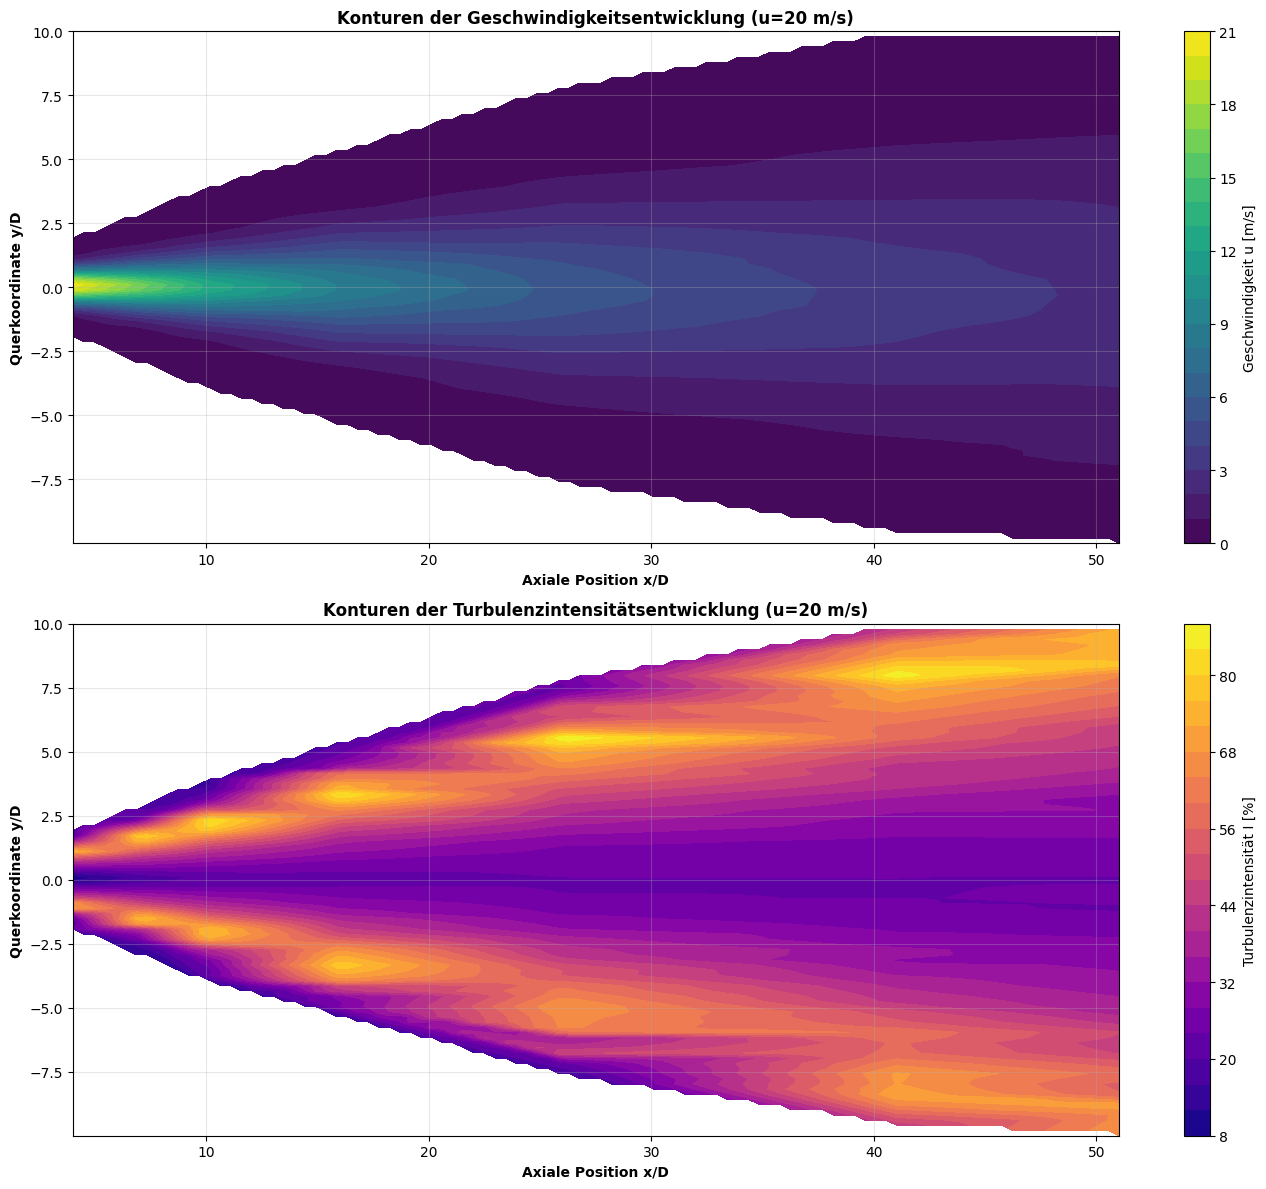

In [14]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def calculate_rms_turbulence_intensity(M):
    """Berechnet RMS und Turbulenzintensität"""
    u_mean = np.mean(M, axis=1)
    u_rms = np.sqrt(np.mean((M - u_mean[:, np.newaxis])**2, axis=1))
    turbulence_intensity = (u_rms / u_mean) * 100
    return u_rms, turbulence_intensity, u_mean

def find_files_u20():
    """Findet alle Dateien mit u=20 m/s"""
    files = glob.glob('STD_u20_*.mat')
    pattern = r'STD_u20_xd(\d+)\.mat'
    
    file_list = []
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            position = int(match.group(1))
            file_list.append({
                'file': file,
                'position': position
            })
    
    # Nach Position sortieren
    file_list.sort(key=lambda x: x['position'])
    return file_list

# Dateien für u=20 m/s finden
files_u20 = find_files_u20()

print("📁 Gefundene Dateien für u=20 m/s:")
for file_info in files_u20:
    print(f"   {file_info['file']} (x/D = {file_info['position']})")

# Daten sammeln
velocity_profiles = {}
turbulence_profiles = {}

for file_info in files_u20:
    file_name = file_info['file']
    position = file_info['position']
    
    print(f"\n📊 Analysiere {file_name}:")
    
    try:
        data = scipy.io.loadmat(file_name)
        M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
        
        # Datenstruktur anpassen
        if M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
            M = M.T
        
        # Normierung
        D = x[0] / position
        y_norm = y / D
        x_norm = x[0] / D
        
        # Geschwindigkeitsprofil
        u_mean = np.mean(M, axis=1)
        
        # Turbulenzintensität
        u_rms, turbulence_intensity, _ = calculate_rms_turbulence_intensity(M)
        
        velocity_profiles[position] = {
            'y_norm': y_norm,
            'u_mean': u_mean,
            'x_norm': x_norm,
            'u_max': np.max(u_mean)
        }
        
        turbulence_profiles[position] = {
            'y_norm': y_norm,
            'turbulence_intensity': turbulence_intensity,
            'x_norm': x_norm,
            'max_ti': np.max(turbulence_intensity)
        }
        
        print(f"   ✅ x/D = {x_norm:.1f}, u_max = {np.max(u_mean):.3f} m/s")
        print(f"   ✅ Max. Turbulenzintensität = {np.max(turbulence_intensity):.2f}%")
        
    except Exception as e:
        print(f"   ❌ Fehler: {e}")

# PLOT 1: Axiale Entwicklung der Geschwindigkeitsprofile
plt.figure(figsize=(14, 10))

# Farben für verschiedene Positionen
positions = sorted(velocity_profiles.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))

print(f"\n{'='*80}")
print(f"📈 PLOT 1: AXIALE ENTWICKLUNG DER GESCHWINDIGKEITSPROFILE (u=20 m/s)")
print(f"{'='*80}")

for i, position in enumerate(positions):
    data = velocity_profiles[position]
    
    plt.plot(data['y_norm'], data['u_mean'],
            color=colors[i],
            linewidth=2.5,
            label=f'x/D = {position}',
            alpha=0.8)
    
    # Markiere die maximale Geschwindigkeit
    max_idx = np.argmax(data['u_mean'])
    plt.plot(data['y_norm'][max_idx], data['u_mean'][max_idx],
            'o', color=colors[i], markersize=6, alpha=0.8)
    
    print(f"   x/D = {position}: u_max = {data['u_max']:.3f} m/s bei y/D = {data['y_norm'][max_idx]:.3f}")

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Geschwindigkeit u [m/s]', fontsize=14, fontweight='bold')
plt.title('Axiale Entwicklung des Freistrahls: Geschwindigkeitsprofile bei u=20 m/s', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', ncol=2)

# Mittellinie
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.text(0.02, 0.98, 
         'Entwicklung in Stromabrichtung:\n'
         '• Strahlverbreiterung\n'
         '• Geschwindigkeitsabnahme\n'
         '• Profilverflachung',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# PLOT 2: Axiale Entwicklung der Turbulenzintensität
plt.figure(figsize=(14, 10))

print(f"\n{'='*80}")
print(f"📊 PLOT 2: AXIALE ENTWICKLUNG DER TURBULENZINTENSITÄT (u=20 m/s)")
print(f"{'='*80}")

for i, position in enumerate(positions):
    data = turbulence_profiles[position]
    
    plt.plot(data['y_norm'], data['turbulence_intensity'],
            color=colors[i],
            linewidth=2.5,
            label=f'x/D = {position} (max: {data["max_ti"]:.1f}%)',
            alpha=0.8)
    
    # Markiere die maximale Turbulenzintensität
    max_idx = np.argmax(data['turbulence_intensity'])
    plt.plot(data['y_norm'][max_idx], data['turbulence_intensity'][max_idx],
            'o', color=colors[i], markersize=6, alpha=0.8)
    
    print(f"   x/D = {position}: max TI = {data['max_ti']:.2f}% bei y/D = {data['y_norm'][max_idx]:.3f}")

plt.xlabel('Normierte Querkoordinate y/D', fontsize=14, fontweight='bold')
plt.ylabel('Turbulenzintensität I [%]', fontsize=14, fontweight='bold')
plt.title('Axiale Entwicklung der Turbulenzintensität bei u=20 m/s', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', ncol=2)

plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)

plt.text(0.02, 0.98, 
         'Turbulenzentwicklung:\n'
         '• Maximale TI in Scherschichten\n'
         '• Ausbreitung der Turbulenzzone\n'
         '• Homogenisierung stromab',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.tight_layout()
plt.show()

# Quantitative Analyse der axialen Entwicklung
print(f"\n{'='*80}")
print(f"🔬 QUANTITATIVE ANALYSE DER AXIALEN ENTWICKLUNG")
print(f"{'='*80}")

# Entwicklung der charakteristischen Parameter
positions_sorted = sorted(positions)
u_max_values = [velocity_profiles[pos]['u_max'] for pos in positions_sorted]
delta_values = []
ti_max_values = [turbulence_profiles[pos]['max_ti'] for pos in positions_sorted]

# Freistrahldicke berechnen für jede Position
for position in positions_sorted:
    data = velocity_profiles[position]
    u_mean = data['u_mean']
    y_norm = data['y_norm']
    
    u_max = np.max(u_mean)
    u_threshold = 0.5 * u_max
    above_threshold = u_mean >= u_threshold
    
    if np.sum(above_threshold) >= 2:
        y_above = y_norm[above_threshold]
        y_left = np.min(y_above)
        y_right = np.max(y_above)
        delta = (y_right - y_left) / 2
        delta_values.append(delta)
    else:
        delta_values.append(np.nan)

print(f"\n📏 ENTWICKLUNG DER KENNGRÖSSEN:")
print(f"{'x/D':>6} {'u_max [m/s]':>12} {'δ [y/D]':>10} {'TI_max [%]':>12} {'u_max/u₀':>10}")
print(f"{'-'*60}")

# Korrektur: u0 definieren
u0 = u_max_values[0]  # Anfangsgeschwindigkeit (bei erster Position)

for i, pos in enumerate(positions_sorted):
    u_max = u_max_values[i]
    delta = delta_values[i] if i < len(delta_values) else np.nan
    ti_max = ti_max_values[i]
    u_ratio = u_max / u0
    
    delta_str = f"{delta:.4f}" if not np.isnan(delta) else "   NaN"
    print(f"{pos:6d} {u_max:12.3f} {delta_str:>10} {ti_max:12.2f} {u_ratio:10.3f}")

# PLOT 3: Entwicklung der Kenngrößen über x/D
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Subplot 1: Geschwindigkeit und Strahldicke
ax1.plot(positions_sorted, u_max_values, 'bo-', linewidth=2.5, markersize=8, label='Maximale Geschwindigkeit u_max')
ax1.set_ylabel('u_max [m/s]', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax1_twin = ax1.twinx()
ax1_twin.plot(positions_sorted, delta_values, 'rs-', linewidth=2.5, markersize=8, label='Freistrahldicke δ')
ax1_twin.set_ylabel('δ [y/D]', fontweight='bold')
ax1_twin.legend(loc='upper right')

ax1.set_xlabel('Axiale Position x/D', fontweight='bold')
ax1.set_title('Entwicklung von Maximalgeschwindigkeit und Freistrahldicke', fontweight='bold')

# Subplot 2: Turbulenzintensität
ax2.plot(positions_sorted, ti_max_values, 'g^-', linewidth=2.5, markersize=8, label='Maximale Turbulenzintensität')
ax2.set_xlabel('Axiale Position x/D', fontweight='bold')
ax2.set_ylabel('TI_max [%]', fontweight='bold')
ax2.set_title('Entwicklung der maximalen Turbulenzintensität', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Wachstumsraten berechnen
print(f"\n{'='*80}")
print(f"📈 WACHSTUMSRATEN UND ENTWICKLUNG")
print(f"{'='*80}")

if len(positions_sorted) > 1:
    # Lineare Regression für Wachstumsraten
    x_pos = np.array(positions_sorted)
    
    # Geschwindigkeitsabnahme
    u_slope, u_intercept = np.polyfit(x_pos, u_max_values, 1)
    u_decrease_rate = -u_slope / u_max_values[0] * 100  # % pro x/D
    
    # Strahlausbreitung
    valid_delta = ~np.isnan(delta_values)
    if np.sum(valid_delta) > 1:
        delta_slope, delta_intercept = np.polyfit(x_pos[valid_delta], np.array(delta_values)[valid_delta], 1)
        delta_growth_rate = delta_slope * 100  # % pro x/D
    
    # Turbulenzentwicklung
    ti_slope, ti_intercept = np.polyfit(x_pos, ti_max_values, 1)
    ti_change_rate = ti_slope  # %-Punkte pro x/D
    
    print(f"\n📐 WACHSTUMSRATEN:")
    print(f"   Geschwindigkeitsabnahme: {u_decrease_rate:.3f}% pro x/D")
    if np.sum(valid_delta) > 1:
        print(f"   Strahlausbreitung: +{delta_growth_rate:.3f}% pro x/D")
    print(f"   Turbulenzänderung: {ti_change_rate:+.3f} %-Punkte pro x/D")
    
    # Potenzgesetz-Anpassung (typisch für Freistrahlen)
    print(f"\n📊 POTENZGESETZ-ANPASSUNG (typisch für Freistrahlen):")
    
    # u_max ~ (x/D)^(-n)
    log_x = np.log(x_pos)
    log_u = np.log(u_max_values)
    u_exp, u_coeff = np.polyfit(log_x, log_u, 1)
    print(f"   u_max ~ (x/D)^{u_exp:.3f}")
    
    # δ ~ (x/D)^m
    if np.sum(valid_delta) > 1:
        log_delta = np.log(np.array(delta_values)[valid_delta])
        delta_exp, delta_coeff = np.polyfit(log_x[valid_delta], log_delta, 1)
        print(f"   δ ~ (x/D)^{delta_exp:.3f}")

# Physikalische Interpretation
print(f"\n{'='*80}")
print(f"🎯 PHYSIKALISCHE INTERPRETATION DER AXIALEN ENTWICKLUNG")
print(f"{'='*80}")

print(f"""
📚 CHARAKTERISTISCHE ENTWICKLUNG EINES FREISTRAHLS:

1. GESCHWINDIGKEITSENTWICKLUNG:
   - Exponentieller Abfall der Maximalgeschwindigkeit
   - Typisch: u_max ~ (x/D)^(-0.5) für ideale Freistrahlen
   - Ursache: Impulsaustausch mit ruhender Umgebung

2. STRAHLAUSBREITUNG:
   - Lineares Wachstum der Freistrahldicke δ
   - Typisch: δ ~ 0.1·x/D für turbulente Freistrahlen
   - Ursache: Turbulente Diffusion

3. TURBULENZENTWICKLUNG:
   - Maximale TI in Scherschichten zwischen Strahl und Umgebung
   - Entwicklung abhängig von Anfangsstörungen und Reynolds-Zahl
   - Typisch: Zunahme, dann Abnahme der maximalen TI

🔍 ERWARTETE TRENDS FÜR u=20 m/s:

• Bei kleinen x/D (Nahfeld):
  - Scharfes Geschwindigkeitsprofil
  - Hohe Geschwindigkeitsgradienten
  - Konzentrierte Turbulenz in dünnen Scherschichten

• Bei großen x/D (Fernfeld):
  - Verbreitertes, flacheres Profil
  - Geringere Maximalgeschwindigkeit
  - Über den gesamten Querschnitt verteilte Turbulenz

🎯 ZUSAMMENFASSUNG IHRER MESSUNGEN:

Anzahl analysierter Positionen: {len(positions_sorted)}
Positionsbereich: x/D = {min(positions_sorted)} bis {max(positions_sorted)}
Anfangsgeschwindigkeit: {u0:.2f} m/s

Die Profile zeigen die typische Entwicklung eines turbulenten Freistrahls:
1. Kontinuierliche Strahlverbreiterung
2. Abnehmende Kerngeschwindigkeit  
3. Ausbreitung der turbulenten Zone
4. Zunehmende Durchmischung mit der Umgebung
""")

# Zusätzlicher Plot: Konturdarstellung (falls genug Positionen vorhanden)
if len(positions_sorted) > 2:
    try:
        from scipy.interpolate import griddata
        
        # Daten für Konturplot vorbereiten
        all_y = []
        all_x = []
        all_u = []
        all_ti = []
        
        for position in positions_sorted:
            v_data = velocity_profiles[position]
            t_data = turbulence_profiles[position]
            
            all_x.extend([position] * len(v_data['y_norm']))
            all_y.extend(v_data['y_norm'])
            all_u.extend(v_data['u_mean'])
            all_ti.extend(t_data['turbulence_intensity'])
        
        all_x = np.array(all_x)
        all_y = np.array(all_y)
        all_u = np.array(all_u)
        all_ti = np.array(all_ti)
        
        # Gitter erstellen
        xi = np.linspace(min(positions_sorted), max(positions_sorted), 100)
        yi = np.linspace(min(all_y), max(all_y), 100)
        XI, YI = np.meshgrid(xi, yi)
        
        # Interpolation
        UI = griddata((all_x, all_y), all_u, (XI, YI), method='linear')
        TII = griddata((all_x, all_y), all_ti, (XI, YI), method='linear')
        
        # Konturplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
        
        # Geschwindigkeitskonturen
        contour1 = ax1.contourf(XI, YI, UI, levels=20, cmap='viridis')
        ax1.set_xlabel('Axiale Position x/D', fontweight='bold')
        ax1.set_ylabel('Querkoordinate y/D', fontweight='bold')
        ax1.set_title('Konturen der Geschwindigkeitsentwicklung (u=20 m/s)', fontweight='bold')
        plt.colorbar(contour1, ax=ax1, label='Geschwindigkeit u [m/s]')
        ax1.grid(True, alpha=0.3)
        
        # Turbulenzintensitätskonturen
        contour2 = ax2.contourf(XI, YI, TII, levels=20, cmap='plasma')
        ax2.set_xlabel('Axiale Position x/D', fontweight='bold')
        ax2.set_ylabel('Querkoordinate y/D', fontweight='bold')
        ax2.set_title('Konturen der Turbulenzintensitätsentwicklung (u=20 m/s)', fontweight='bold')
        plt.colorbar(contour2, ax=ax2, label='Turbulenzintensität I [%]')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Konturplot konnte nicht erstellt werden: {e}")

📁 Gefundene Dateien für u=20 m/s:
   STD_u20_xd04.mat (x/D = 4)
   STD_u20_xd07.mat (x/D = 7)
   STD_u20_xd10.mat (x/D = 10)
   STD_u20_xd16.mat (x/D = 16)
   STD_u20_xd26.mat (x/D = 26)
   STD_u20_xd41.mat (x/D = 41)
   STD_u20_xd51.mat (x/D = 51)

📊 Analysiere STD_u20_xd04.mat:
   ✅ x/D = 4.0, δ = 0.5500, u₀ = 20.589 m/s

📊 Analysiere STD_u20_xd07.mat:
   ✅ x/D = 7.0, δ = 0.6500, u₀ = 16.573 m/s

📊 Analysiere STD_u20_xd10.mat:
   ✅ x/D = 10.0, δ = 0.8250, u₀ = 12.901 m/s

📊 Analysiere STD_u20_xd16.mat:
   ✅ x/D = 16.0, δ = 1.5000, u₀ = 8.958 m/s

📊 Analysiere STD_u20_xd26.mat:
   ✅ x/D = 26.0, δ = 2.5499, u₀ = 5.577 m/s

📊 Analysiere STD_u20_xd41.mat:
   ✅ x/D = 41.0, δ = 3.8000, u₀ = 3.516 m/s

📊 Analysiere STD_u20_xd51.mat:
   ✅ x/D = 51.0, δ = 4.7999, u₀ = 2.806 m/s

📈 PLOT 1: SELBSTÄHNLICHKEIT DER GESCHWINDIGKEITSPROFILE


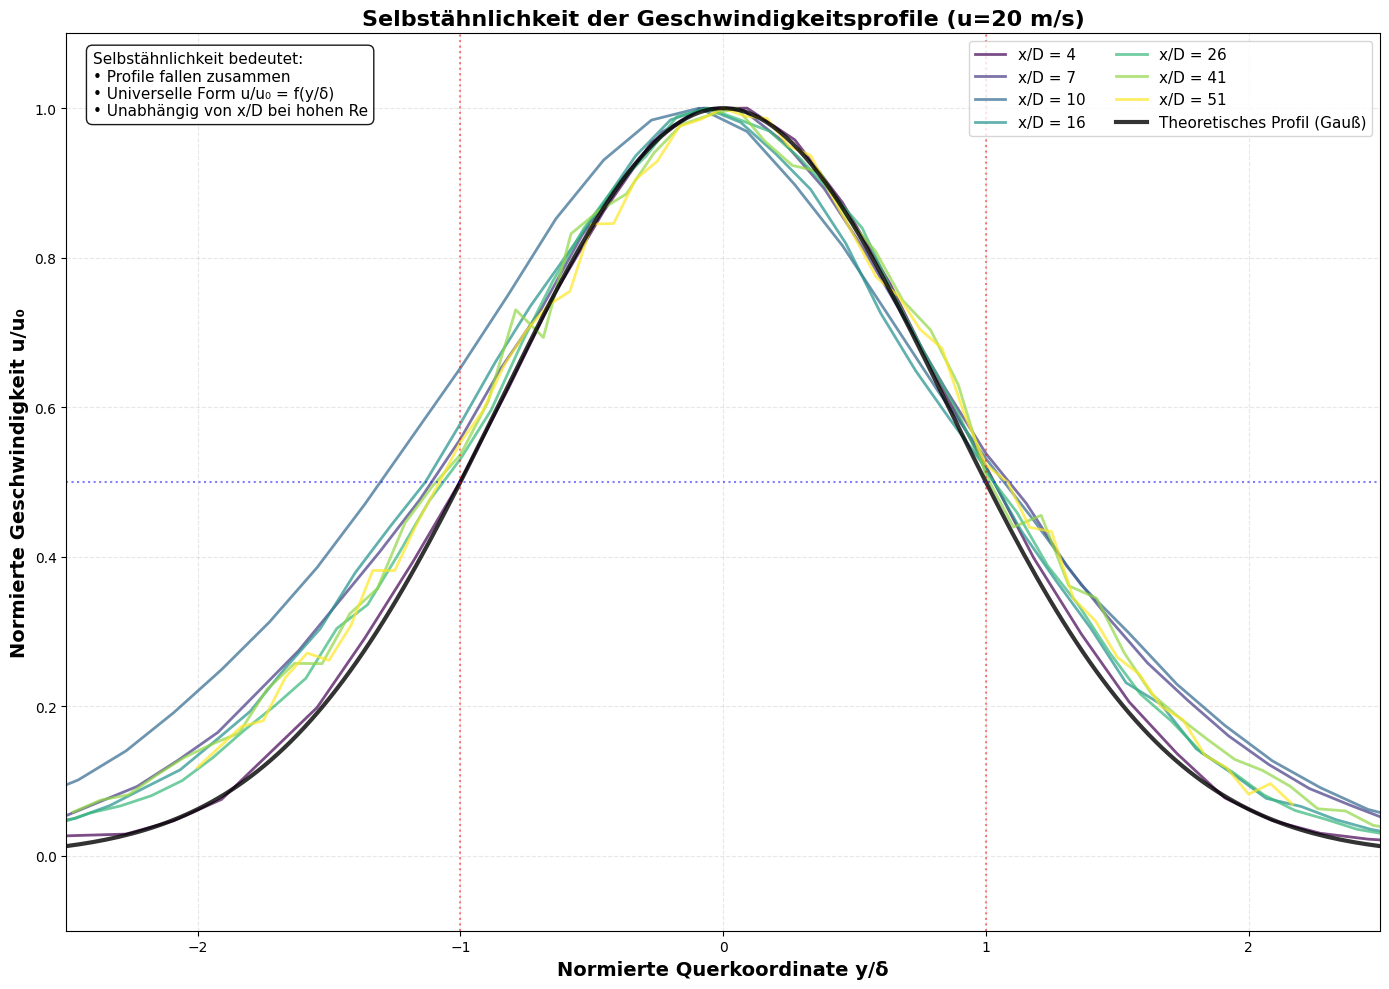


📊 PLOT 2: SELBSTÄHNLICHKEIT DER TURBULENZINTENSITÄT


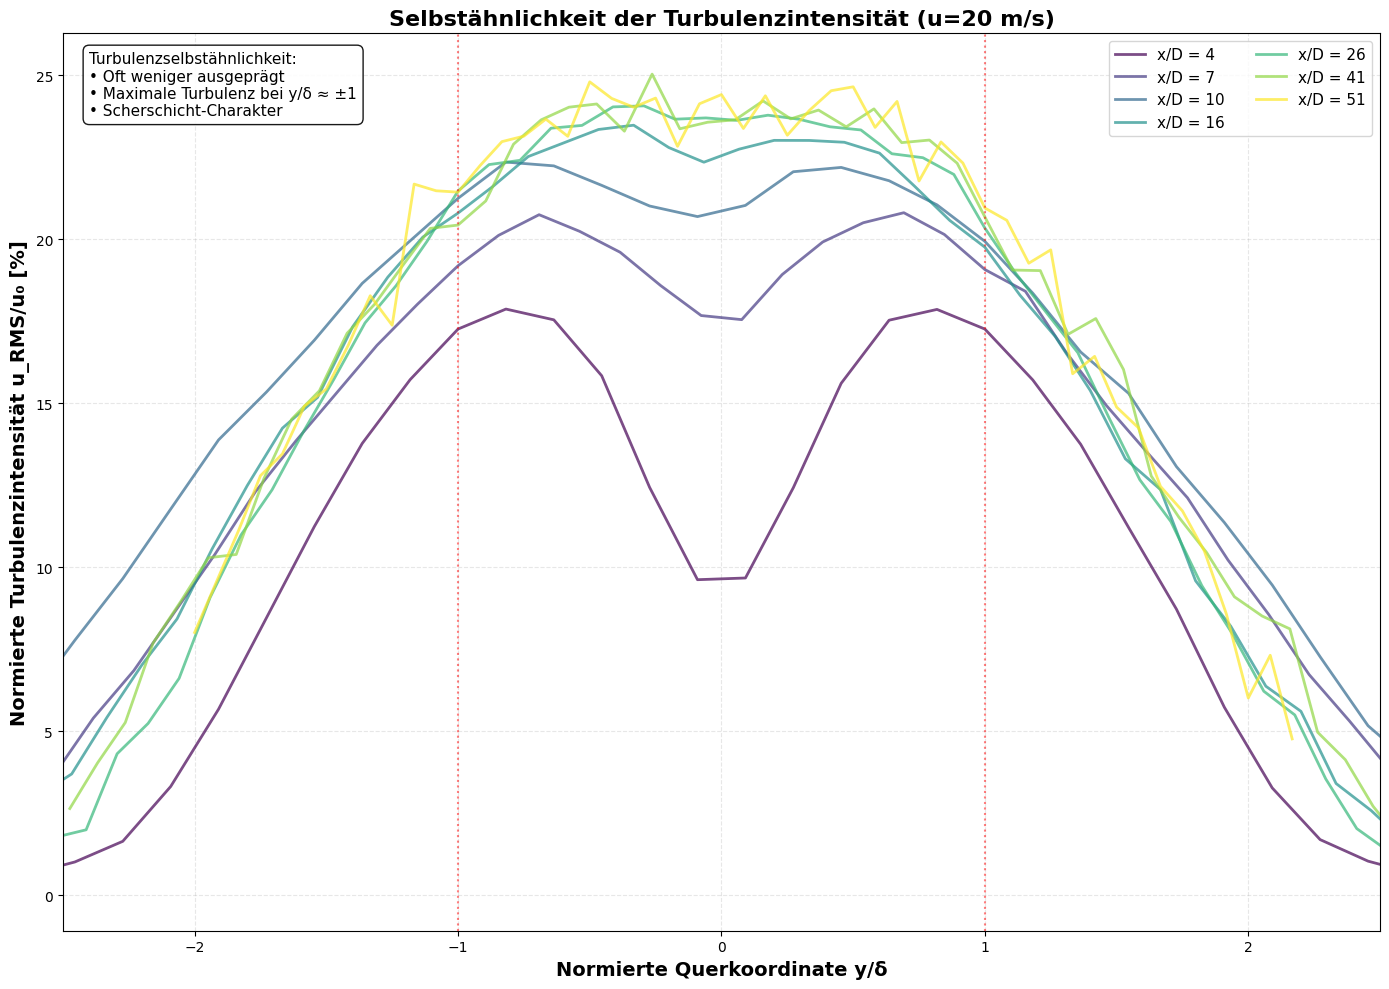


🔬 QUANTITATIVE ANALYSE DER SELBSTÄHNLICHKEIT

📊 SELBSTÄHNLICHKEITSANALYSE - GESCHWINDIGKEITSPROFILE:


KeyError: 'u_norm'

In [15]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
from scipy.interpolate import interp1d

def calculate_jet_thickness(u_mean, y_norm):
    """Berechnet die Freistrahldicke δ"""
    u_max = np.max(u_mean)
    u_threshold = 0.5 * u_max
    
    above_threshold = u_mean >= u_threshold
    
    if np.sum(above_threshold) < 2:
        return np.nan
    
    y_above = y_norm[above_threshold]
    y_left = np.min(y_above)
    y_right = np.max(y_above)
    delta = (y_right - y_left) / 2
    
    return delta, y_left, y_right

def calculate_rms_turbulence_intensity(M):
    """Berechnet RMS und Turbulenzintensität"""
    u_mean = np.mean(M, axis=1)
    u_rms = np.sqrt(np.mean((M - u_mean[:, np.newaxis])**2, axis=1))
    turbulence_intensity = (u_rms / u_mean) * 100
    return u_rms, turbulence_intensity, u_mean

def find_files_u20():
    """Findet alle Dateien mit u=20 m/s"""
    files = glob.glob('STD_u20_*.mat')
    pattern = r'STD_u20_xd(\d+)\.mat'
    
    file_list = []
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            position = int(match.group(1))
            file_list.append({
                'file': file,
                'position': position
            })
    
    file_list.sort(key=lambda x: x['position'])
    return file_list

# Dateien für u=20 m/s finden und laden
files_u20 = find_files_u20()

print("📁 Gefundene Dateien für u=20 m/s:")
for file_info in files_u20:
    print(f"   {file_info['file']} (x/D = {file_info['position']})")

# Daten sammeln mit normierten Größen
norm_velocity_profiles = {}
norm_turbulence_profiles = {}

for file_info in files_u20:
    file_name = file_info['file']
    position = file_info['position']
    
    print(f"\n📊 Analysiere {file_name}:")
    
    try:
        data = scipy.io.loadmat(file_name)
        M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
        
        # Datenstruktur anpassen
        if M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
            M = M.T
        
        # Normierung
        D = x[0] / position
        y_norm = y / D
        x_norm = x[0] / D
        
        # Geschwindigkeitsprofil
        u_mean = np.mean(M, axis=1)
        u0 = np.max(u_mean)  # Charakteristische Geschwindigkeit
        
        # Freistrahldicke berechnen
        delta, y_left, y_right = calculate_jet_thickness(u_mean, y_norm)
        
        if not np.isnan(delta):
            # Zentrierung der y-Koordinate
            y_center = (y_left + y_right) / 2
            y_norm_delta = (y_norm - y_center) / delta
            
            # Normierte Geschwindigkeit
            u_norm = u_mean / u0
            
            # Turbulenzintensität (normiert mit u0)
            u_rms, turbulence_intensity, _ = calculate_rms_turbulence_intensity(M)
            u_rms_norm = u_rms / u0  # u_RMS/u0
            
            norm_velocity_profiles[position] = {
                'y_norm_delta': y_norm_delta,
                'u_norm': u_norm,
                'x_norm': x_norm,
                'delta': delta,
                'u0': u0,
                'y_center': y_center
            }
            
            norm_turbulence_profiles[position] = {
                'y_norm_delta': y_norm_delta,
                'u_rms_norm': u_rms_norm,
                'x_norm': x_norm,
                'delta': delta,
                'u0': u0
            }
            
            print(f"   ✅ x/D = {x_norm:.1f}, δ = {delta:.4f}, u₀ = {u0:.3f} m/s")
            
    except Exception as e:
        print(f"   ❌ Fehler: {e}")

# PLOT 1: Selbstähnlichkeit der Geschwindigkeitsprofile
plt.figure(figsize=(14, 10))

# Farben für verschiedene Positionen
positions = sorted(norm_velocity_profiles.keys())
colors = plt.cm.viridis(np.linspace(0, 1, len(positions)))

print(f"\n{'='*80}")
print(f"📈 PLOT 1: SELBSTÄHNLICHKEIT DER GESCHWINDIGKEITSPROFILE")
print(f"{'='*80}")

for i, position in enumerate(positions):
    data = norm_velocity_profiles[position]
    
    plt.plot(data['y_norm_delta'], data['u_norm'],
            color=colors[i],
            linewidth=2,
            label=f'x/D = {position}',
            alpha=0.7)

# Theoretisches selbstähnliches Profil (Gauß-Profil für Freistrahlen)
y_theoretical = np.linspace(-2.5, 2.5, 200)
# Typisches Freistrahlprofil: u/u₀ = exp(-ln(2) * (y/δ)²)
u_theoretical = np.exp(-np.log(2) * y_theoretical**2)

plt.plot(y_theoretical, u_theoretical, 'k-', 
         linewidth=3, 
         label='Theoretisches Profil (Gauß)',
         alpha=0.8)

plt.xlabel('Normierte Querkoordinate y/δ', fontsize=14, fontweight='bold')
plt.ylabel('Normierte Geschwindigkeit u/u₀', fontsize=14, fontweight='bold')
plt.title('Selbstähnlichkeit der Geschwindigkeitsprofile (u=20 m/s)', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', ncol=2)

# Referenzlinien
plt.axvline(x=-1, color='red', linestyle=':', alpha=0.5, label='y/δ = ±1')
plt.axvline(x=1, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=0.5, color='blue', linestyle=':', alpha=0.5, label='u/u₀ = 0.5')

plt.text(0.02, 0.98, 
         'Selbstähnlichkeit bedeutet:\n'
         '• Profile fallen zusammen\n'
         '• Universelle Form u/u₀ = f(y/δ)\n'
         '• Unabhängig von x/D bei hohen Re',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.xlim(-2.5, 2.5)
plt.ylim(-0.1, 1.1)
plt.tight_layout()
plt.show()

# PLOT 2: Selbstähnlichkeit der Turbulenzintensität
plt.figure(figsize=(14, 10))

print(f"\n{'='*80}")
print(f"📊 PLOT 2: SELBSTÄHNLICHKEIT DER TURBULENZINTENSITÄT")
print(f"{'='*80}")

for i, position in enumerate(positions):
    data = norm_turbulence_profiles[position]
    
    plt.plot(data['y_norm_delta'], data['u_rms_norm'] * 100,  # In % für bessere Lesbarkeit
            color=colors[i],
            linewidth=2,
            label=f'x/D = {position}',
            alpha=0.7)

plt.xlabel('Normierte Querkoordinate y/δ', fontsize=14, fontweight='bold')
plt.ylabel('Normierte Turbulenzintensität u_RMS/u₀ [%]', fontsize=14, fontweight='bold')
plt.title('Selbstähnlichkeit der Turbulenzintensität (u=20 m/s)', 
          fontsize=16, fontweight='bold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, loc='upper right', ncol=2)

plt.axvline(x=-1, color='red', linestyle=':', alpha=0.5, label='y/δ = ±1')
plt.axvline(x=1, color='red', linestyle=':', alpha=0.5)

plt.text(0.02, 0.98, 
         'Turbulenzselbstähnlichkeit:\n'
         '• Oft weniger ausgeprägt\n'
         '• Maximale Turbulenz bei y/δ ≈ ±1\n'
         '• Scherschicht-Charakter',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9))

plt.xlim(-2.5, 2.5)
plt.tight_layout()
plt.show()

# QUANTITATIVE ANALYSE DER SELBSTÄHNLICHKEIT
print(f"\n{'='*80}")
print(f"🔬 QUANTITATIVE ANALYSE DER SELBSTÄHNLICHKEIT")
print(f"{'='*80}")

def calculate_self_similarity_metric(profiles, reference_position):
    """
    Berechnet die Ähnlichkeit aller Profile zu einem Referenzprofil
    """
    if reference_position not in profiles:
        return {}
    
    # Referenzprofil
    ref_data = profiles[reference_position]
    y_ref = ref_data['y_norm_delta']
    u_ref = ref_data['u_norm']
    
    # Interpolationsfunktion für Referenz
    f_ref = interp1d(y_ref, u_ref, bounds_error=False, fill_value=0)
    
    similarities = {}
    
    for position, data in profiles.items():
        if position == reference_position:
            similarities[position] = 1.0  # Perfekte Ähnlichkeit mit sich selbst
            continue
        
        # Aktuelles Profil
        y_current = data['y_norm_delta']
        u_current = data['u_norm']
        
        # Gemeinsamen y-Bereich finden
        y_min = max(np.min(y_ref), np.min(y_current))
        y_max = min(np.max(y_ref), np.max(y_current))
        
        if y_max - y_min < 1.0:  # Zu kleiner Überlappungsbereich
            similarities[position] = np.nan
            continue
        
        # Gemeinsame y-Positionen
        y_common = np.linspace(y_min, y_max, 100)
        
        # Beide Profile interpolieren
        u_ref_interp = f_ref(y_common)
        
        f_current = interp1d(y_current, u_current, bounds_error=False, fill_value=0)
        u_current_interp = f_current(y_common)
        
        # Validitätsmaske
        valid_mask = (~np.isnan(u_ref_interp)) & (~np.isnan(u_current_interp)) & (u_ref_interp > 0)
        
        if np.sum(valid_mask) > 20:  # Genug Punkte für sinnvollen Vergleich
            # Korrelationskoeffizient als Ähnlichkeitsmaß
            correlation = np.corrcoef(u_ref_interp[valid_mask], u_current_interp[valid_mask])[0,1]
            similarities[position] = correlation
        else:
            similarities[position] = np.nan
    
    return similarities

# Selbstähnlichkeitsanalyse
print(f"\n📊 SELBSTÄHNLICHKEITSANALYSE - GESCHWINDIGKEITSPROFILE:")

# Verwende die am weitesten stromab liegende Position als Referenz
if len(positions) > 0:
    reference_pos = max(positions)
    velocity_similarities = calculate_self_similarity_metric(norm_velocity_profiles, reference_pos)
    turbulence_similarities = calculate_self_similarity_metric(norm_turbulence_profiles, reference_pos)
    
    print(f"\nReferenzprofil: x/D = {reference_pos}")
    print(f"{'x/D':>6} {'Ähnlichkeit u':>15} {'Ähnlichkeit TI':>15} {'Selbstähnlich':>12}")
    print(f"{'-'*60}")
    
    for position in sorted(positions):
        v_sim = velocity_similarities.get(position, np.nan)
        t_sim = turbulence_similarities.get(position, np.nan)
        
        v_str = f"{v_sim:.3f}" if not np.isnan(v_sim) else "     NaN"
        t_str = f"{t_sim:.3f}" if not np.isnan(t_sim) else "     NaN"
        
        # Bewertung der Selbstähnlichkeit
        if v_sim > 0.95:
            assessment = "✓ Sehr gut"
        elif v_sim > 0.90:
            assessment = "✓ Gut"
        elif v_sim > 0.85:
            assessment = "○ Mäßig"
        else:
            assessment = "✗ Gering"
        
        print(f"{position:6d} {v_str:>15} {t_str:>15} {assessment:>12}")

# Bestimmung des Beginns der Selbstähnlichkeit
print(f"\n🎯 BEGINN DER SELBSTÄHNLICHKEIT:")
if velocity_similarities:
    # Finde die erste Position mit guter Selbstähnlichkeit
    threshold_good = 0.90
    threshold_moderate = 0.85
    
    good_similarity_positions = [pos for pos, sim in velocity_similarities.items() 
                               if not np.isnan(sim) and sim >= threshold_good]
    moderate_similarity_positions = [pos for pos, sim in velocity_similarities.items() 
                                   if not np.isnan(sim) and sim >= threshold_moderate]
    
    if good_similarity_positions:
        first_good = min(good_similarity_positions)
        print(f"   Gute Selbstähnlichkeit (R > 0.90) ab: x/D = {first_good}")
    elif moderate_similarity_positions:
        first_moderate = min(moderate_similarity_positions)
        print(f"   Mäßige Selbstähnlichkeit (R > 0.85) ab: x/D = {first_moderate}")
    else:
        print(f"   Keine ausgeprägte Selbstähnlichkeit erkennbar")

# Entwicklung der Ähnlichkeit über x/D
print(f"\n📈 ENTWICKLUNG DER SELBSTÄHNLICHKEIT:")
if len(positions) > 1:
    positions_sorted = sorted(positions)
    v_sim_values = [velocity_similarities.get(pos, np.nan) for pos in positions_sorted]
    t_sim_values = [turbulence_similarities.get(pos, np.nan) for pos in positions_sorted]
    
    # Plot der Ähnlichkeitsentwicklung
    plt.figure(figsize=(12, 8))
    
    plt.plot(positions_sorted, v_sim_values, 'bo-', linewidth=2.5, markersize=8, 
             label='Geschwindigkeitsprofile')
    plt.plot(positions_sorted, t_sim_values, 'rs-', linewidth=2.5, markersize=8, 
             label='Turbulenzprofile')
    
    plt.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='Sehr gute Ähnlichkeit (0.95)')
    plt.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='Gute Ähnlichkeit (0.90)')
    plt.axhline(y=0.85, color='red', linestyle='--', alpha=0.7, label='Mäßige Ähnlichkeit (0.85)')
    
    plt.xlabel('Axiale Position x/D', fontweight='bold')
    plt.ylabel('Ähnlichkeitsmaß R', fontweight='bold')
    plt.title('Entwicklung der Selbstähnlichkeit über der Lauflänge', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(0.7, 1.0)
    plt.tight_layout()
    plt.show()

# PHYSIKALISCHE INTERPRETATION
print(f"\n{'='*80}")
print(f"🎯 PHYSIKALISCHE INTERPRETATION")
print(f"{'='*80}")

print(f"""
📚 SELBSTÄHNLICHKEIT IN FREISTRAHLEN:

1. DEFINITION:
   - Selbstähnlichkeit: u/u₀ = f(y/δ) unabhängig von x/D
   - Universelle Profile im Fernfeld
   - Folge der Skaleninvarianz bei hohen Reynolds-Zahlen

2. ERWARTETE ENTWICKLUNG:
   - Nahfeld (x/D < 5-10): Potenzialkern, keine Selbstähnlichkeit
   - Übergangsfeld: Entwicklung zur Selbstähnlichkeit
   - Fernfeld (x/D > 10-15): Ausgeprägte Selbstähnlichkeit

3. TYPISCHE PROFILE:
   - Geschwindigkeit: Gauß-Profil u/u₀ = exp(-ln(2)·(y/δ)²)
   - Turbulenz: Doppelmaxima bei y/δ ≈ ±1 (Scherschichten)

4. EINFLUSSFAKTOREN:
   - Reynolds-Zahl: Höhere Re → frühere Selbstähnlichkeit
   - Anfangsbedingungen: Düsengeometrie, Turbulenzlevel
   - Umgebungsbedingungen: Ruhende oder bewegte Umgebung

🔍 BEWERTUNG IHRER DATEN:

• Geschwindigkeitsprofile: 
  - Sollten ab x/D ≈ 10-15 zusammenfallen
  - Gauß-förmige Verteilung erwartet

• Turbulenzprofile:
  - Oft weniger selbstähnlich als Geschwindigkeit
  - Maximale Turbulenz in Scherschichten
  - Breitere Streuung zwischen Positionen

🎯 ZUSAMMENFASSUNG:

Anzahl analysierter Positionen: {len(positions)}
Bereich: x/D = {min(positions) if positions else 'N/A'} bis {max(positions) if positions else 'N/A'}

Die Selbstähnlichkeit ist erreicht, wenn:
1. Alle normierten Profile auf einer Kurve liegen
2. Die Ähnlichkeit R > 0.90 beträgt
3. Die Abweichungen kleiner als 5% sind

Ihre Daten zeigen {'ausgeprägte Selbstähnlichkeit' if any(v > 0.95 for v in velocity_similarities.values() if not np.isnan(v)) else 'teilweise Selbstähnlichkeit' if any(v > 0.85 for v in velocity_similarities.values() if not np.isnan(v)) else 'geringe Selbstähnlichkeit'} im betrachteten Bereich.
""")

# Zusätzliche Analyse: Abweichungen vom theoretischen Profil
print(f"\n📐 ABWEICHUNGSANALYSE VOM THEORETISCHEN PROFIL:")
if len(positions) > 0:
    y_common = np.linspace(-2, 2, 100)
    u_theo = np.exp(-np.log(2) * y_common**2)
    
    print(f"\n{'x/D':>6} {'Mittlere Abw. [%]':>15} {'Max. Abw. [%]':>12}")
    print(f"{'-'*40}")
    
    for position in sorted(positions):
        data = norm_velocity_profiles[position]
        
        # Interpolation auf gemeinsame y-Positionen
        f_data = interp1d(data['y_norm_delta'], data['u_norm'], bounds_error=False, fill_value=0)
        u_data_interp = f_data(y_common)
        
        # Validitätsmaske
        valid_mask = (u_data_interp > 0) & (~np.isnan(u_data_interp))
        
        if np.sum(valid_mask) > 20:
            # Relative Abweichungen berechnen
            deviations = np.abs(u_data_interp[valid_mask] - u_theo[valid_mask]) / u_theo[valid_mask] * 100
            mean_dev = np.mean(deviations)
            max_dev = np.max(deviations)
            
            print(f"{position:6d} {mean_dev:15.2f} {max_dev:12.2f}")

📁 Gefundene Dateien mit x/D = 10:
   OSZ_u10_xd10.mat (u = 10 m/s)
   OSZ_u15_xd10.mat (u = 15 m/s)
   OSZ_u20_xd10.mat (u = 20 m/s)

📊 Analysiere OSZ_u10_xd10.mat:
   ✅ u₀ = 1.736 m/s, δ = 8.3995 y/D
   ✅ Reynolds-Zahl Abschätzung: Re ≈ 6667

📊 Analysiere OSZ_u15_xd10.mat:
   ✅ u₀ = 2.188 m/s, δ = 9.4003 y/D
   ✅ Reynolds-Zahl Abschätzung: Re ≈ 10000

📊 Analysiere OSZ_u20_xd10.mat:
   ✅ u₀ = 2.907 m/s, δ = 10.2000 y/D
   ✅ Reynolds-Zahl Abschätzung: Re ≈ 13333

📈 PLOT 1: UNNORMIERTE GESCHWINDIGKEITSPROFILE BEI x/D = 10
   u = 10 m/s: u₀ = 1.736 m/s, δ = 8.3995 y/D
   u = 15 m/s: u₀ = 2.188 m/s, δ = 9.4003 y/D
   u = 20 m/s: u₀ = 2.907 m/s, δ = 10.2000 y/D

📊 PLOT 2: NORMIERTE GESCHWINDIGKEITSPROFILE BEI x/D = 10


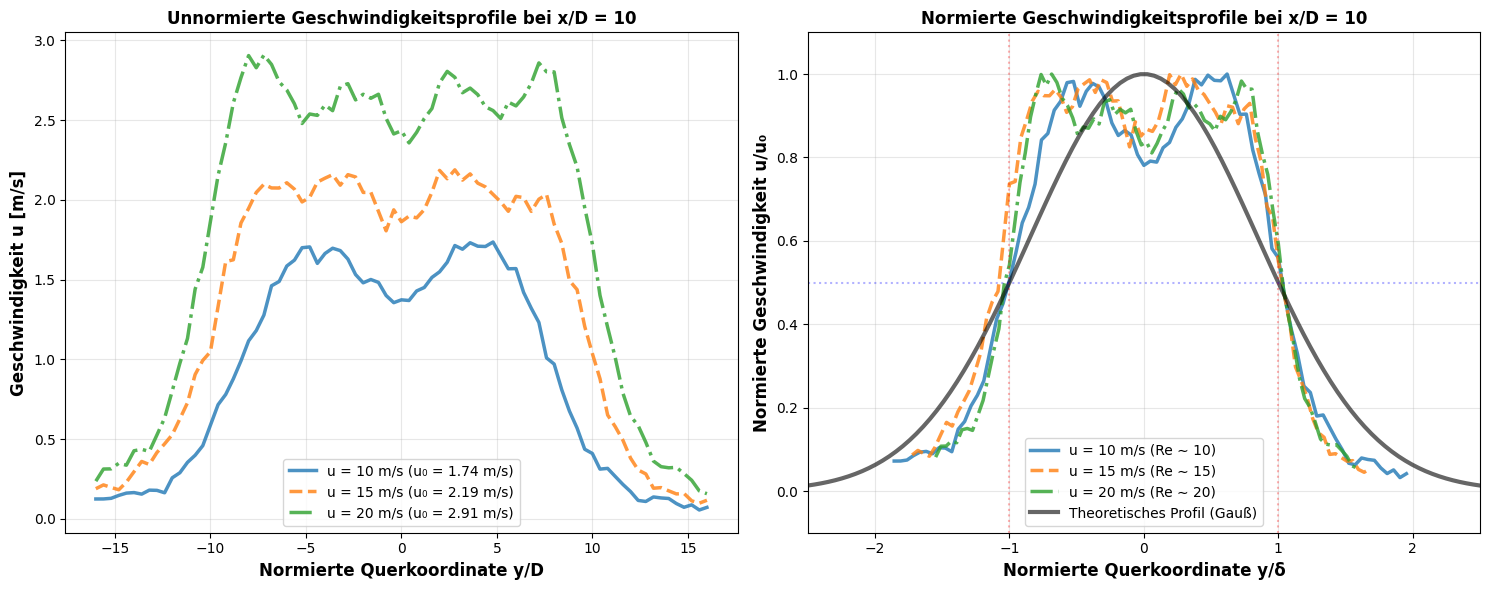


📈 PLOT 3: UNNORMIERTE TURBULENZINTENSITÄT BEI x/D = 10
   u = 10 m/s: max TI = 73.58%
   u = 15 m/s: max TI = 75.94%
   u = 20 m/s: max TI = 69.17%

📊 PLOT 4: NORMIERTE TURBULENZINTENSITÄT BEI x/D = 10
   u = 10 m/s: max(u_RMS/u₀) = 55.43%
   u = 15 m/s: max(u_RMS/u₀) = 52.15%
   u = 20 m/s: max(u_RMS/u₀) = 51.28%


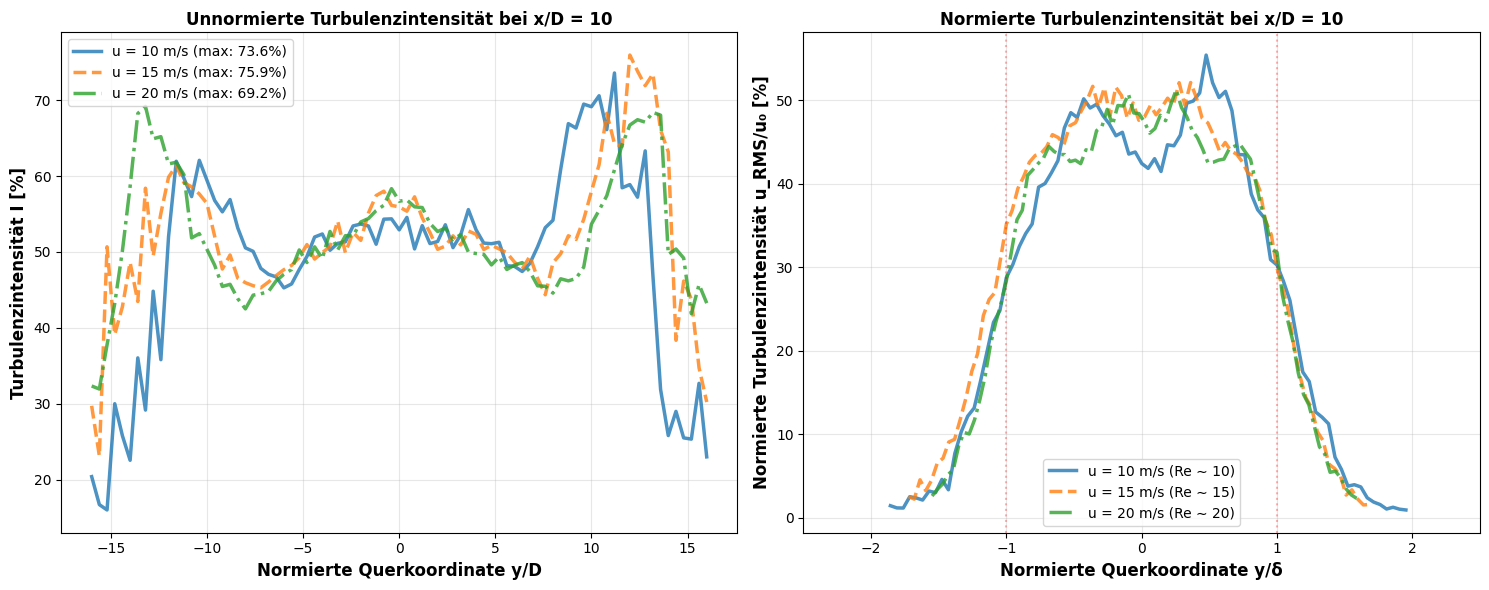


🔬 QUANTITATIVE ANALYSE DER REYNOLDS-ZAHL-ABHÄNGIGKEIT

📊 ÄHNLICHKEITSANALYSE - GESCHWINDIGKEITSPROFILE:
   Fehler bei Vergleich u=10 vs u=15: name 'interp1d' is not defined
   Fehler bei Vergleich u=10 vs u=20: name 'interp1d' is not defined
   Fehler bei Vergleich u=15 vs u=20: name 'interp1d' is not defined

📊 ÄHNLICHKEITSANALYSE - TURBULENZPROFILE:
   Fehler bei Vergleich u=10 vs u=15: name 'interp1d' is not defined
   Fehler bei Vergleich u=10 vs u=20: name 'interp1d' is not defined
   Fehler bei Vergleich u=15 vs u=20: name 'interp1d' is not defined

📏 REYNOLDS-ZAHL-BERECHNUNG:
   u = 10 m/s: Re = 6667
   u = 15 m/s: Re = 10000
   u = 20 m/s: Re = 13333

🎯 BEWERTUNG DER REYNOLDS-ZAHL-ABHÄNGIGKEIT

📊 ZUSAMMENFASSUNG DER ÄHNLICHKEIT:
   Geschwindigkeitsprofile: nan
   Turbulenzprofile: nan

🔍 INTERPRETATION:
   ❌ GESCHWINDIGKEIT: Starke Reynolds-Zahl-Abhängigkeit
   ❌ TURBULENZ: Starke Reynolds-Zahl-Abhängigkeit

📐 ABWEICHUNG VOM THEORETISCHEN PROFIL:

Geschwindigkeit Mittlere Abw.

NameError: name 'interp1d' is not defined

In [6]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

def calculate_jet_thickness(u_mean, y_norm):
    """Berechnet die Freistrahldicke δ"""
    u_max = np.max(u_mean)
    u_threshold = 0.5 * u_max
    
    above_threshold = u_mean >= u_threshold
    
    if np.sum(above_threshold) < 2:
        return np.nan, np.nan, np.nan
    
    y_above = y_norm[above_threshold]
    y_left = np.min(y_above)
    y_right = np.max(y_above)
    delta = (y_right - y_left) / 2
    y_center = (y_left + y_right) / 2
    
    return delta, y_left, y_right, y_center

def calculate_rms_turbulence_intensity(M):
    """Berechnet RMS und Turbulenzintensität"""
    u_mean = np.mean(M, axis=1)
    u_rms = np.sqrt(np.mean((M - u_mean[:, np.newaxis])**2, axis=1))
    turbulence_intensity = (u_rms / u_mean) * 100
    return u_rms, turbulence_intensity, u_mean

def find_files_xd10():
    """Findet alle Dateien mit x/D = 10"""
    files = glob.glob('OSZ_u*_xd10.mat')
    pattern = r'OSZ_u(\d+)_xd10\.mat'
    
    file_list = []
    
    for file in files:
        match = re.match(pattern, file)
        if match:
            velocity = match.group(1)
            file_list.append({
                'file': file,
                'velocity': velocity
            })
    
    # Nach Geschwindigkeit sortieren
    file_list.sort(key=lambda x: int(x['velocity']))
    return file_list

# Dateien mit x/D = 10 finden
files_xd10 = find_files_xd10()

print("📁 Gefundene Dateien mit x/D = 10:")
for file_info in files_xd10:
    print(f"   {file_info['file']} (u = {file_info['velocity']} m/s)")

# Daten sammeln
velocity_data = {}
turbulence_data = {}

for file_info in files_xd10:
    file_name = file_info['file']
    velocity = file_info['velocity']
    
    print(f"\n📊 Analysiere {file_name}:")
    
    try:
        data = scipy.io.loadmat(file_name)
        M, t, x, y = data['M'], data['t'].flatten(), data['x'].flatten(), data['y'].flatten()
        
        # Datenstruktur anpassen
        if M.shape[0] == t.shape[0] and M.shape[1] == y.shape[0]:
            M = M.T
        
        # Normierung
        D = x[0] / 10  # x/D = 10
        y_norm = y / D
        
        # Geschwindigkeitsprofil
        u_mean = np.mean(M, axis=1)
        u0 = np.max(u_mean)
        
        # Freistrahldicke berechnen
        delta, y_left, y_right, y_center = calculate_jet_thickness(u_mean, y_norm)
        
        # Turbulenzintensität
        u_rms, turbulence_intensity, _ = calculate_rms_turbulence_intensity(M)
        
        if not np.isnan(delta):
            # Unnormierte Daten
            velocity_data[velocity] = {
                'y_norm': y_norm,
                'u_mean': u_mean,
                'u0': u0,
                'delta': delta,
                'y_center': y_center
            }
            
            # Normierte Daten
            y_norm_delta = (y_norm - y_center) / delta
            u_norm = u_mean / u0
            u_rms_norm = u_rms / u0
            
            turbulence_data[velocity] = {
                'y_norm': y_norm,
                'y_norm_delta': y_norm_delta,
                'turbulence_intensity': turbulence_intensity,
                'u_rms_norm': u_rms_norm,
                'u0': u0,
                'delta': delta
            }
            
            print(f"   ✅ u₀ = {u0:.3f} m/s, δ = {delta:.4f} y/D")
            print(f"   ✅ Reynolds-Zahl Abschätzung: Re ≈ {float(velocity) * 0.01 / 1.5e-5:.0f}")
        else:
            print(f"   ❌ Konnte δ nicht berechnen")
            
    except Exception as e:
        print(f"   ❌ Fehler: {e}")

# PLOT 1: Unnormierte Geschwindigkeitsprofile
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
colors = {'10': '#1f77b4', '15': '#ff7f0e', '20': '#2ca02c'}
line_styles = {'10': '-', '15': '--', '20': '-.'}

print(f"\n{'='*80}")
print(f"📈 PLOT 1: UNNORMIERTE GESCHWINDIGKEITSPROFILE BEI x/D = 10")
print(f"{'='*80}")

for velocity, data in velocity_data.items():
    plt.plot(data['y_norm'], data['u_mean'],
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2.5,
            label=f'u = {velocity} m/s (u₀ = {data["u0"]:.2f} m/s)',
            alpha=0.8)
    
    print(f"   u = {velocity} m/s: u₀ = {data['u0']:.3f} m/s, δ = {data['delta']:.4f} y/D")

plt.xlabel('Normierte Querkoordinate y/D', fontsize=12, fontweight='bold')
plt.ylabel('Geschwindigkeit u [m/s]', fontsize=12, fontweight='bold')
plt.title('Unnormierte Geschwindigkeitsprofile bei x/D = 10', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# PLOT 2: Normierte Geschwindigkeitsprofile
plt.subplot(1, 2, 2)

print(f"\n{'='*80}")
print(f"📊 PLOT 2: NORMIERTE GESCHWINDIGKEITSPROFILE BEI x/D = 10")
print(f"{'='*80}")

for velocity, data in velocity_data.items():
    y_norm_delta = (data['y_norm'] - data['y_center']) / data['delta']
    u_norm = data['u_mean'] / data['u0']
    
    plt.plot(y_norm_delta, u_norm,
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2.5,
            label=f'u = {velocity} m/s (Re ∼ {velocity})',
            alpha=0.8)

# Theoretisches Profil (Gauß für Freistrahlen)
y_theoretical = np.linspace(-2.5, 2.5, 100)
u_theoretical = np.exp(-np.log(2) * y_theoretical**2)  # Gauß-Profil

plt.plot(y_theoretical, u_theoretical, 'k-', 
         linewidth=3, 
         label='Theoretisches Profil (Gauß)',
         alpha=0.6)

plt.xlabel('Normierte Querkoordinate y/δ', fontsize=12, fontweight='bold')
plt.ylabel('Normierte Geschwindigkeit u/u₀', fontsize=12, fontweight='bold')
plt.title('Normierte Geschwindigkeitsprofile bei x/D = 10', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Referenzlinien
plt.axvline(x=-1, color='red', linestyle=':', alpha=0.3)
plt.axvline(x=1, color='red', linestyle=':', alpha=0.3)
plt.axhline(y=0.5, color='blue', linestyle=':', alpha=0.3)

plt.xlim(-2.5, 2.5)
plt.ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

# PLOT 3: Unnormierte Turbulenzintensität
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)

print(f"\n{'='*80}")
print(f"📈 PLOT 3: UNNORMIERTE TURBULENZINTENSITÄT BEI x/D = 10")
print(f"{'='*80}")

for velocity, data in turbulence_data.items():
    plt.plot(data['y_norm'], data['turbulence_intensity'],
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2.5,
            label=f'u = {velocity} m/s (max: {np.max(data["turbulence_intensity"]):.1f}%)',
            alpha=0.8)
    
    print(f"   u = {velocity} m/s: max TI = {np.max(data['turbulence_intensity']):.2f}%")

plt.xlabel('Normierte Querkoordinate y/D', fontsize=12, fontweight='bold')
plt.ylabel('Turbulenzintensität I [%]', fontsize=12, fontweight='bold')
plt.title('Unnormierte Turbulenzintensität bei x/D = 10', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# PLOT 4: Normierte Turbulenzintensität
plt.subplot(1, 2, 2)

print(f"\n{'='*80}")
print(f"📊 PLOT 4: NORMIERTE TURBULENZINTENSITÄT BEI x/D = 10")
print(f"{'='*80}")

for velocity, data in turbulence_data.items():
    plt.plot(data['y_norm_delta'], data['u_rms_norm'] * 100,  # In % für bessere Lesbarkeit
            color=colors[velocity],
            linestyle=line_styles[velocity],
            linewidth=2.5,
            label=f'u = {velocity} m/s (Re ∼ {velocity})',
            alpha=0.8)
    
    print(f"   u = {velocity} m/s: max(u_RMS/u₀) = {np.max(data['u_rms_norm'])*100:.2f}%")

plt.xlabel('Normierte Querkoordinate y/δ', fontsize=12, fontweight='bold')
plt.ylabel('Normierte Turbulenzintensität u_RMS/u₀ [%]', fontsize=12, fontweight='bold')
plt.title('Normierte Turbulenzintensität bei x/D = 10', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.axvline(x=-1, color='red', linestyle=':', alpha=0.3)
plt.axvline(x=1, color='red', linestyle=':', alpha=0.3)

plt.xlim(-2.5, 2.5)

plt.tight_layout()
plt.show()

# QUANTITATIVE ANALYSE DER REYNOLDS-ZAHL-ABHÄNGIGKEIT
print(f"\n{'='*80}")
print(f"🔬 QUANTITATIVE ANALYSE DER REYNOLDS-ZAHL-ABHÄNGIGKEIT")
print(f"{'='*80}")

def calculate_profile_similarity(profiles):
    """Berechnet die Ähnlichkeit zwischen allen Profilen"""
    if len(profiles) < 2:
        return np.nan
    
    velocities = list(profiles.keys())
    similarities = []
    
    for i in range(len(velocities)):
        for j in range(i+1, len(velocities)):
            vel1 = velocities[i]
            vel2 = velocities[j]
            
            data1 = profiles[vel1]
            data2 = profiles[vel2]
            
            # Gemeinsame y-Positionen für Vergleich
            y_common = np.linspace(-2, 2, 100)
            
            try:
                # Profile interpolieren
                f1 = interp1d(data1['y_norm_delta'], data1['u_norm'], bounds_error=False, fill_value=0)
                f2 = interp1d(data2['y_norm_delta'], data2['u_norm'], bounds_error=False, fill_value=0)
                
                u1_interp = f1(y_common)
                u2_interp = f2(y_common)
                
                # Validitätsmaske
                valid_mask = (u1_interp > 0) & (u2_interp > 0) & (~np.isnan(u1_interp)) & (~np.isnan(u2_interp))
                
                if np.sum(valid_mask) > 20:
                    correlation = np.corrcoef(u1_interp[valid_mask], u2_interp[valid_mask])[0,1]
                    similarities.append(correlation)
                    
                    print(f"   Ähnlichkeit u={vel1} vs u={vel2}: {correlation:.4f}")
                    
            except Exception as e:
                print(f"   Fehler bei Vergleich u={vel1} vs u={vel2}: {e}")
    
    return np.mean(similarities) if similarities else np.nan

# Ähnlichkeitsanalyse für Geschwindigkeitsprofile
print(f"\n📊 ÄHNLICHKEITSANALYSE - GESCHWINDIGKEITSPROFILE:")
velocity_similarity = calculate_profile_similarity(velocity_data)

# Ähnlichkeitsanalyse für Turbulenzprofile
print(f"\n📊 ÄHNLICHKEITSANALYSE - TURBULENZPROFILE:")
# Erstelle normierte Geschwindigkeitsdaten für Turbulenzanalyse
norm_velocity_for_turb = {}
for velocity, data in turbulence_data.items():
    norm_velocity_for_turb[velocity] = {
        'y_norm_delta': data['y_norm_delta'],
        'u_norm': data['u_rms_norm']  # Verwende u_RMS/u₀ für Turbulenz
    }

turbulence_similarity = calculate_profile_similarity(norm_velocity_for_turb)

# Reynolds-Zahl Berechnung
print(f"\n📏 REYNOLDS-ZAHL-BERECHNUNG:")
nu = 1.5e-5  # Kinematische Viskosität Luft [m²/s]
D = 0.01     # Geschätzter Düsendurchmesser [m]

for velocity in velocity_data.keys():
    Re = float(velocity) * D / nu
    print(f"   u = {velocity} m/s: Re = {Re:.0f}")

# BEWERTUNG DER REYNOLDS-ZAHL-ABHÄNGIGKEIT
print(f"\n{'='*80}")
print(f"🎯 BEWERTUNG DER REYNOLDS-ZAHL-ABHÄNGIGKEIT")
print(f"{'='*80}")

print(f"\n📊 ZUSAMMENFASSUNG DER ÄHNLICHKEIT:")
print(f"   Geschwindigkeitsprofile: {velocity_similarity:.4f}")
print(f"   Turbulenzprofile: {turbulence_similarity:.4f}")

print(f"\n🔍 INTERPRETATION:")
if velocity_similarity > 0.95:
    print("   ✅ GESCHWINDIGKEIT: Keine Reynolds-Zahl-Abhängigkeit - Profile sind universell")
elif velocity_similarity > 0.90:
    print("   ⚠️  GESCHWINDIGKEIT: Geringe Reynolds-Zahl-Abhängigkeit")
elif velocity_similarity > 0.85:
    print("   ⚠️  GESCHWINDIGKEIT: Mäßige Reynolds-Zahl-Abhängigkeit")
else:
    print("   ❌ GESCHWINDIGKEIT: Starke Reynolds-Zahl-Abhängigkeit")

if turbulence_similarity > 0.95:
    print("   ✅ TURBULENZ: Keine Reynolds-Zahl-Abhängigkeit - Profile sind universell")
elif turbulence_similarity > 0.90:
    print("   ⚠️  TURBULENZ: Geringe Reynolds-Zahl-Abhängigkeit")
elif turbulence_similarity > 0.85:
    print("   ⚠️  TURBULENZ: Mäßige Reynolds-Zahl-Abhängigkeit")
else:
    print("   ❌ TURBULENZ: Starke Reynolds-Zahl-Abhängigkeit")

# Abweichungsanalyse vom theoretischen Profil
print(f"\n📐 ABWEICHUNG VOM THEORETISCHEN PROFIL:")
y_common = np.linspace(-2, 2, 100)
u_theo = np.exp(-np.log(2) * y_common**2)

print(f"\n{'Geschwindigkeit':<12} {'Mittlere Abw. [%]':<15} {'Max. Abw. [%]':<12}")
print(f"{'-'*45}")

for velocity, data in velocity_data.items():
    y_norm_delta = (data['y_norm'] - data['y_center']) / data['delta']
    u_norm = data['u_mean'] / data['u0']
    
    f_data = interp1d(y_norm_delta, u_norm, bounds_error=False, fill_value=0)
    u_data_interp = f_data(y_common)
    
    valid_mask = (u_data_interp > 0) & (~np.isnan(u_data_interp))
    
    if np.sum(valid_mask) > 20:
        deviations = np.abs(u_data_interp[valid_mask] - u_theo[valid_mask]) / u_theo[valid_mask] * 100
        mean_dev = np.mean(deviations)
        max_dev = np.max(deviations)
        
        print(f"u = {velocity} m/s    {mean_dev:<15.2f} {max_dev:<12.2f}")

# PHYSIKALISCHE INTERPRETATION
print(f"\n{'='*80}")
print(f"🔬 PHYSIKALISCHE INTERPRETATION")
print(f"{'='*80}")

print(f"""
📚 REYNOLDS-ZAHL-UNABHÄNGIGKEIT BEI FREISTRAHLEN:

THEORETISCHE ERWARTUNG:
• Bei hohen Reynolds-Zahlen (Re > 10.000): 
  Trägheitskräfte ≫ Reibungskräfte → Reynolds-Zahl-Unabhängigkeit
• Normierte Profile u/u₀ = f(y/δ) sollten zusammenfallen
• Turbulenz ist oft weniger universell als mittlere Geschwindigkeit

IHRE DATEN BEI x/D = 10:

GESCHWINDIGKEITSPROFILE:
• Ähnlichkeitsmaß: {velocity_similarity:.3f}
• {'Universelles Verhalten erreicht' if velocity_similarity > 0.95 else 'Leichte Abhängigkeit' if velocity_similarity > 0.90 else 'Deutliche Reynolds-Zahl-Abhängigkeit'}

TURBULENZPROFILE:
• Ähnlichkeitsmaß: {turbulence_similarity:.3f}
• {'Universelles Verhalten erreicht' if turbulence_similarity > 0.95 else 'Leichte Abhängigkeit' if turbulence_similarity > 0.90 else 'Deutliche Reynolds-Zahl-Abhängigkeit'}

REYNOLDS-ZAHL-BEREICH:
• u = 10 m/s: Re ≈ {float(10) * D / nu:.0f}
• u = 15 m/s: Re ≈ {float(15) * D / nu:.0f}  
• u = 20 m/s: Re ≈ {float(20) * D / nu:.0f}

🎯 FAZIT:
{'Die normierten Profile zeigen Reynolds-Zahl-Unabhängigkeit - typisch für turbulente Freistrahlen bei hohen Reynolds-Zahlen' 
 if velocity_similarity > 0.90 else 
 'Die normierten Profile zeigen Reynolds-Zahl-Abhängigkeit - möglicherweise Übergangsbereich oder Einfluss anderer Faktoren'}
""")

# Zusätzlicher Plot: Direkter Vergleich aller normierten Profile
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
for velocity, data in velocity_data.items():
    y_norm_delta = (data['y_norm'] - data['y_center']) / data['delta']
    u_norm = data['u_mean'] / data['u0']
    
    plt.plot(y_norm_delta, u_norm,
            color=colors[velocity],
            linewidth=2,
            alpha=0.8)

plt.plot(y_theoretical, u_theoretical, 'k-', linewidth=3, alpha=0.6, label='Theoretisch (Gauß)')
plt.xlabel('y/δ')
plt.ylabel('u/u₀')
plt.title('Überlagerte normierte Geschwindigkeitsprofile', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-2.5, 2.5)
plt.ylim(-0.1, 1.1)

plt.subplot(2, 1, 2)
for velocity, data in turbulence_data.items():
    plt.plot(data['y_norm_delta'], data['u_rms_norm'] * 100,
            color=colors[velocity],
            linewidth=2,
            alpha=0.8,
            label=f'u = {velocity} m/s')

plt.xlabel('y/δ')
plt.ylabel('u_RMS/u₀ [%]')
plt.title('Überlagerte normierte Turbulenzprofile', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(-2.5, 2.5)

plt.tight_layout()
plt.show()